### Прогнозирование стоимости недвижимости
#### Выполняли: Билалова.И, Полуэктова.П

Цель проекта: проанализировать рынок жилой недвижимости Турции на основе
датасета Zingat и построить модель прогноза стоимости объекта в рублях.


### *Этап 1. Исследование данных (EDA)*

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Загрузка данных

In [4]:
df = pd.read_csv('real_estate_data.csv',low_memory=False)

In [5]:
# Оставляем поля объявлений; исторические курсы прочитаем из того же CSV ниже.
BASE_COLUMNS = [
    "id", "type", "sub_type", "start_date", "end_date", "listing_type",
    "tom", "building_age", "total_floor_count", "floor_no", "room_count",
    "size", "address", "furnished", "heating_type", "price",
    "price_currency"
]

missing_columns = sorted(set(BASE_COLUMNS) - set(df.columns))
if missing_columns:
    raise ValueError(f"В исходном файле отсутствуют столбцы: {missing_columns}")

df = df[BASE_COLUMNS].copy()

for column in ["id", "tom", "size", "price"]:
    df[column] = pd.to_numeric(df[column], errors="coerce")

print("Загружено строк:", f"{len(df):,}")


Загружено строк: 403,487


## Перевод датасета

In [6]:
# Переводим подписи категорий, не изменяя числовые типы данных.
MAP_TYPE = {"Konut": "Жилая"}

MAP_SUB = {
    "Rezidans": "Резиденция", "Daire": "Квартира", "Villa": "Вилла",
    "Müstakil Ev": "Отдельный дом", "Yazlık": "Дача",
    "Kooperatif": "Кооператив", "Komple Bina": "Целое здание",
    "Prefabrik Ev": "Сборный дом", "Çiftlik Evi": "Фермерский дом",
    "Köşk / Konak / Yalı": "Особняк / Конак / У воды",
    "Yalı Dairesi": "Квартира у воды", "Loft": "Лофт",
}

MAP_LISTING = {"1": "Продажа", "2": "Аренда", "3": "Другое"}

MAP_FLOOR = {
    "Yüksek Giriş": "Высокий первый этаж", "Giriş Katı": "Первый этаж",
    "Bahçe katı": "Садовый этаж", "Asma Kat": "Антресоль",
    "Zemin Kat": "Цокольный этаж", "Kot 1": "Подвал 1",
    "Kot 2": "Подвал 2", "Kot 3": "Подвал 3", "Kot 4": "Подвал 4",
    "Bodrum Kat": "Подвал", "Çatı Katı": "Мансарда",
    "Teras Kat": "Этаж с террасой", "En Üst Kat": "Последний этаж",
    "Müstakil": "Отдельный", "Komple": "Целиком",
}

MAP_FLOOR_COUNT = {
    "20 ve üzeri": "20+", "10-20 arası": "10-20",
    **MAP_FLOOR,
}

MAP_HEATING = {
    "Fancoil": "Фанкойл", "Kalorifer (Doğalgaz)": "Центральное отопление (газ)",
    "Kalorifer (Kömür)": "Центральное отопление (уголь)",
    "Kombi (Doğalgaz)": "Котёл (газ)",
    "Kombi (Elektrikli)": "Котёл (электрический)",
    "Klima": "Кондиционер", "Merkezi Sistem": "Центральная система",
    "Merkezi Sistem (Isı Payı Ölçer)": "Центральная система (счётчик тепла)",
    "Soba (Kömür)": "Печь (уголь)", "Soba (Doğalgaz)": "Печь (газ)",
    "Yerden Isıtma": "Тёплый пол", "Kat Kaloriferi": "Поквартирное отопление",
    "Güneş Enerjisi": "Солнечная энергия", "Jeotermal": "Геотермальное",
}

MAP_CITY = {
    "İstanbul": "Стамбул", "Ankara": "Анкара", "İzmir": "Измир",
    "Muğla": "Мугла", "Antalya": "Анталья", "Bursa": "Бурса",
    "Adana": "Адана", "Konya": "Конья", "Gaziantep": "Газиантеп",
    "Mersin": "Мерсин", "Kayseri": "Кайсери", "Eskişehir": "Эскишехир",
    "Samsun": "Самсун", "Denizli": "Денизли", "Şanlıurfa": "Шанлыурфа",
    "Malatya": "Малатья", "Trabzon": "Трабзон", "Erzurum": "Эрзурум",
    "Balıkesir": "Балыкесир", "Manisa": "Маниса", "Aydın": "Айдын",
    "Tekirdağ": "Текирдаг", "Çanakkale": "Чанаккале",
    "Sakarya": "Сакарья", "Kocaeli": "Коджаэли", "Yalova": "Ялова",
    "Edirne": "Эдирне", "Kırklareli": "Кыркларели", "Bilecik": "Биледжик",
    "Bolu": "Болу", "Düzce": "Дюздже", "Zonguldak": "Зонгулдак",
    "Karabük": "Карабюк", "Kastamonu": "Кастамону", "Sinop": "Синоп",
    "Amasya": "Амасья", "Çorum": "Чорум", "Yozgat": "Йозгат",
    "Sivas": "Сивас", "Tokat": "Токат", "Ordu": "Орду",
    "Giresun": "Гиресун", "Rize": "Ризе", "Artvin": "Артвин",
    "Erzincan": "Эрзинджан", "Ağrı": "Агры", "Van": "Ван",
    "Diyarbakır": "Диярбакыр", "Mardin": "Мардин", "Batman": "Батман",
    "Siirt": "Сиирт", "Şırnak": "Шырнак", "Hatay": "Хатай",
    "Osmaniye": "Османие", "Kahramanmaraş": "Кахраманмараш",
    "Adıyaman": "Адыяман", "Elazığ": "Элязыг", "Tunceli": "Тунджели",
    "Bingöl": "Бингёль", "Muş": "Муш", "Bitlis": "Битлис",
    "Hakkari": "Хаккяри", "Kars": "Карс", "Ardahan": "Ардахан",
    "Iğdır": "Ыгдыр", "Nevşehir": "Невшехир", "Kırşehir": "Кыршехир",
    "Kırıkkale": "Кырыккале", "Aksaray": "Аксарай", "Niğde": "Нигде",
    "Karaman": "Караман", "Isparta": "Ыспарта", "Burdur": "Бурдур",
    "Afyonkarahisar": "Афьонкарахисар", "Kütahya": "Кютахья",
    "Uşak": "Ушак", "Çankırı": "Чанкыры", "Bartın": "Бартын",
    "Gümüşhane": "Гюмюшхане", "Bayburt": "Байбурт", "Kilis": "Килис",
    "KKTC": "ТРСК",
}

for column in ["type", "sub_type", "listing_type", "floor_no",
               "total_floor_count", "heating_type"]:
    df[column] = df[column].astype("string").str.strip()

df["type"] = df["type"].replace(MAP_TYPE)
df["sub_type"] = df["sub_type"].replace(MAP_SUB)
df["listing_type"] = df["listing_type"].replace(MAP_LISTING)
df["floor_no"] = df["floor_no"].replace(MAP_FLOOR)
df["total_floor_count"] = df["total_floor_count"].replace(MAP_FLOOR_COUNT)
df["heating_type"] = df["heating_type"].replace(MAP_HEATING)

address_parts = df["address"].astype("string").str.split("/")
df["city"] = address_parts.str[0].str.strip().replace(MAP_CITY)
df["district"] = address_parts.str[1].fillna("Неизвестно").str.strip()

# Полностью пустой столбец не несёт информации для анализа и модели.
df = df.drop(columns=["furnished"], errors="ignore")

df.to_csv(translated_path, index=False, encoding="utf-8-sig")
print("Сохранён подготовленный набор:", translated_path)
print("Размер:", df.shape)


Сохранён подготовленный набор: C:\Users\ilnar\Downloads\4 Kyrc\translated_final.csv
Размер: (403487, 18)


In [7]:
# Рабочая копия для пересчёта всех исходных валют в единую валюту.
df_prices = df.copy()

print("Проверка переведённых категорий:")
for column in ["type", "sub_type", "listing_type"]:
    print(column, "-", df_prices[column].dropna().unique()[:5])


Проверка переведённых категорий:
type - <StringArray>
['Жилая']
Length: 1, dtype: string
sub_type - <StringArray>
['Резиденция', 'Квартира', 'Вилла', 'Отдельный дом', 'Кооператив']
Length: 5, dtype: string
listing_type - <StringArray>
['Аренда', 'Продажа', 'Другое']
Length: 3, dtype: string


### Повторная загрузка подготовленного датасета


In [19]:
# Повторная загрузка проверяет, что сохранённый CSV воспроизводимо читается.
df = pd.read_csv(translated_path, low_memory=False)

for column in ["id", "tom", "size", "price"]:
    df[column] = pd.to_numeric(df[column], errors="coerce")

df_prices = df.copy()
print("Размер:", df.shape)
print("Числовые типы:")
display(df[["id", "tom", "size", "price"]].dtypes.to_frame("dtype"))


Размер: (403487, 18)
Числовые типы:


,dtype
id,int64
tom,int64
size,float64
price,float64


In [20]:
df.head()

,id,type,sub_type,start_date,end_date,listing_type,tom,building_age,total_floor_count,floor_no,room_count,size,address,heating_type,price,price_currency,city,district
0,1,Жилая,Резиденция,12/10/18,1/9/19,Аренда,30,0,20+,2,2+1,90.0,İstanbul/Kartal/Kordonboyu,Фанкойл,3500.0,TRY,Стамбул,Kartal
1,2,Жилая,Квартира,2/13/19,NaN,Продажа,14,0,20+,20 ve üzeri,1+0,43.0,İstanbul/Kartal/Kordonboyu,Фанкойл,490000.0,TRY,Стамбул,Kartal
2,3,Жилая,Квартира,10/9/18,11/8/18,Продажа,30,0,1,Высокий первый этаж,2+1,NaN,Tekirdağ/Çorlu/Reşadiye,Фанкойл,155000.0,TRY,Текирдаг,Çorlu
3,4,Жилая,Резиденция,9/10/18,10/10/18,Продажа,30,3,20+,20 ve üzeri,6+1,450.0,İstanbul/Beşiktaş/Levent,Фанкойл,32500000.0,TRY,Стамбул,Beşiktaş
4,5,Жилая,Резиденция,12/10/18,1/9/19,Продажа,30,0,20+,2,2+1,90.0,İstanbul/Kartal/Kordonboyu,Фанкойл,1450000.0,TRY,Стамбул,Kartal


In [ ]:
RATE_COLUMNS = ["USD", "GBP", "TRY", "RUB"]

# Берём исторические курсы из исходного файла и оставляем по одной строке на дату.
rates = pd.read_csv(
    data_path,
    usecols=["start_date", *RATE_COLUMNS],
    low_memory=False,
)
rates["Date"] = pd.to_datetime(
    rates["start_date"], format="%m/%d/%y", errors="raise"
)
rates = rates.drop(columns="start_date").drop_duplicates(subset="Date")
for column in RATE_COLUMNS:
    rates[column] = pd.to_numeric(rates[column], errors="coerce")
rates["EUR"] = 1.0
rates = rates.set_index("Date")[RATE_COLUMNS + ["EUR"]].sort_index()

dates = pd.to_datetime(
    df_prices["start_date"], format="%m/%d/%y", errors="raise"
)

# Для выходных и праздников берём последний опубликованный курс не старше 7 дней.
row_rates = rates.reindex(dates, method="ffill", tolerance=pd.Timedelta(days=7))
row_rates.index = df_prices.index

known_currency = df_prices["price_currency"].isin(["TRY", "EUR", "GBP", "USD"])
known_price = pd.to_numeric(df_prices["price"], errors="coerce").notna()
required_rows = known_currency & known_price

if row_rates.loc[required_rows, ["TRY", "RUB"]].isna().any().any():
    raise ValueError("Не для всех объявлений найдены исторические курсы.")

# Повторный запуск ячейки безопасен: старые валютные столбцы сначала удаляются.
df_prices = df_prices.drop(
    columns=["USD", "GBP", "TRY", "RUB", "EUR"], errors="ignore"
).join(row_rates)

print("Исторические курсы присоединены")
display(df_prices[["start_date", "price_currency", "price", "TRY", "RUB"]].head())


In [22]:
df_prices[["start_date", "price_currency", "price", "TRY", "RUB"]].head()


,start_date,price_currency,price,TRY,RUB
0,12/10/18,TRY,3500.0,6.0499,75.8985
1,2/13/19,TRY,490000.0,5.9383,74.3338
2,10/9/18,TRY,155000.0,7.0183,76.3635
3,9/10/18,TRY,32500000.0,7.4763,81.2688
4,12/10/18,TRY,1450000.0,6.0499,75.8985


In [23]:
# price_try нужен как прозрачный промежуточный расчёт перед переводом в рубли.
df_prices["price"] = pd.to_numeric(df_prices["price"], errors="coerce")
df_prices["price_try"] = np.nan

for currency in ["TRY", "EUR", "GBP", "USD"]:
    mask = df_prices["price_currency"].eq(currency)
    rate_to_try = row_rates.loc[mask, "TRY"] / row_rates.loc[mask, currency]
    df_prices.loc[mask, "price_try"] = (
        df_prices.loc[mask, "price"] * rate_to_try
    )


In [24]:
# Количество рублей за одну турецкую лиру на дату публикации объявления.
rub_per_try = row_rates["RUB"] / row_rates["TRY"]
df_prices["price_rub"] = df_prices["price_try"] * rub_per_try

display(
    df_prices[
        ["start_date", "price_currency", "price", "price_try", "price_rub"]
    ]
    .head(10)
    .style.format(precision=2, thousands=" ", decimal=",", na_rep="—")
)


,start_date,price_currency,price,price_try,price_rub
0,12/10/18,TRY,"3 500,00","3 500,00","43 908,95"
1,2/13/19,TRY,"490 000,00","490 000,00","6 133 668,22"
2,10/9/18,TRY,"155 000,00","155 000,00","1 686 497,09"
3,9/10/18,TRY,"32 500 000,00","32 500 000,00","353 281 168,49"
4,12/10/18,TRY,"1 450 000,00","1 450 000,00","18 190 850,26"
5,11/9/18,TRY,"780 000,00","780 000,00","9 574 866,13"
6,1/4/19,TRY,"3 750,00","3 750,00","47 206,35"
7,10/3/18,TRY,"1 500 000,00","1 500 000,00","16 225 384,68"
8,2/16/19,TRY,"1 500 000,00","1 500 000,00","18 984 929,71"
9,12/26/18,GBP,"84 256,00","565 961,36","7 308 088,34"


In [25]:
df_prices.head()


,id,type,sub_type,start_date,end_date,listing_type,tom,building_age,total_floor_count,floor_no,...,price_currency,city,district,USD,GBP,TRY,RUB,EUR,price_try,price_rub
0,1,Жилая,Резиденция,12/10/18,1/9/19,Аренда,30,0,20+,2,...,TRY,Стамбул,Kartal,1.1425,0.90245,6.0499,75.8985,1.0,3500.0,4.390895e+04
1,2,Жилая,Квартира,2/13/19,NaN,Продажа,14,0,20+,20 ve üzeri,...,TRY,Стамбул,Kartal,1.1305,0.87553,5.9383,74.3338,1.0,490000.0,6.133668e+06
2,3,Жилая,Квартира,10/9/18,11/8/18,Продажа,30,0,1,Высокий первый этаж,...,TRY,Текирдаг,Çorlu,1.1435,0.87680,7.0183,76.3635,1.0,155000.0,1.686497e+06
3,4,Жилая,Резиденция,9/10/18,10/10/18,Продажа,30,3,20+,20 ve üzeri,...,TRY,Стамбул,Beşiktaş,1.1571,0.89340,7.4763,81.2688,1.0,32500000.0,3.532812e+08
4,5,Жилая,Резиденция,12/10/18,1/9/19,Продажа,30,0,20+,2,...,TRY,Стамбул,Kartal,1.1425,0.90245,6.0499,75.8985,1.0,1450000.0,1.819085e+07


Для сопоставления цен разных исходных валют создана таблица `df_prices`.

- `price_try` — промежуточная цена в турецких лирах;
- `price_rub` — итоговая цена в рублях и целевая переменная модели.

Пересчёт выполняется по историческим курсам на дату начала объявления
`start_date`. Если на конкретную дату курса нет, используется последний
предыдущий опубликованный курс не старше семи дней. Исходные `price` и
`price_currency` сохраняются для контроля, а отсутствующие цены не заполняются.


#### Описание данных

**Источник:** Zingat — данные объявлений о жилой недвижимости.

Основные признаки:
* **id** — идентификатор объявления
* **type** — тип недвижимости
* **sub_type** — подтип объекта
* **start_date / end_date** — даты активности объявления
* **listing_type** — тип объявления
* **tom** — время нахождения на рынке
* **building_age** — возраст здания
* **total_floor_count** — количество этажей
* **floor_no** — этаж
* **room_count** — количество комнат
* **size** — площадь, м²
* **address** — адрес
* **furnished** — меблированность
* **heating_type** — тип отопления
* **price** — цена
* **price_currency** — валюта цены

**Основная целевая переменная после пересчета:** `price_try`.

In [26]:
print("Последние 5 строк датасета:")
display(df.tail())

Последние 5 строк датасета:


,id,type,sub_type,start_date,end_date,listing_type,tom,building_age,total_floor_count,floor_no,room_count,size,address,heating_type,price,price_currency,city,district
403482,403483,Жилая,Квартира,9/18/18,NaN,Аренда,162,NaN,NaN,NaN,+,NaN,İstanbul/Sultanbeyli/Adil,NaN,1500.0,TRY,Стамбул,Sultanbeyli
403483,403484,Жилая,Квартира,10/11/18,NaN,Продажа,139,NaN,NaN,NaN,2+1,NaN,Sakarya/Adapazarı/Cumhuriyet,NaN,120000.0,TRY,Сакарья,Adapazarı
403484,403485,Жилая,Квартира,11/22/18,NaN,Продажа,97,NaN,NaN,NaN,1+1,NaN,Antalya/Alanya/Saray,NaN,48000.0,EUR,Анталья,Alanya
403485,403486,Жилая,Квартира,2/21/19,NaN,Аренда,6,NaN,NaN,NaN,2+1,2.0,Aydın/Kuşadası/Türkmen,NaN,900.0,TRY,Айдын,Kuşadası
403486,403487,Жилая,Квартира,1/15/19,1/18/19,Продажа,3,NaN,NaN,NaN,3+1,140.0,Kayseri/Melikgazi/Alpaslan,NaN,210000.0,TRY,Кайсери,Melikgazi


In [27]:
print("\nСлучайная строка:")
display(df.sample(1, random_state=42))


Случайная строка:


,id,type,sub_type,start_date,end_date,listing_type,tom,building_age,total_floor_count,floor_no,room_count,size,address,heating_type,price,price_currency,city,district
60623,60624,Жилая,Квартира,11/20/18,2/23/19,Продажа,95,6-10 arası,5,1,2+1,120.0,Antalya/Alanya/Oba,Кондиционер,240000.0,TRY,Анталья,Alanya


In [28]:
# Сравниваем типы объявлений уже после пересчёта всех валют в RUB.
type_summary = (
    df_prices.loc[df_prices["price_rub"].gt(0)]
    .groupby("listing_type")["price_rub"]
    .agg(["count", "median"])
    .rename(columns={
        "count": "Количество объявлений",
        "median": "Медианная цена, RUB",
    })
)
display(type_summary)


,Количество объявлений,"Медианная цена, RUB"
listing_type,,
Аренда,114101,1.413226e+04
Другое,2234,8.655565e+02
Продажа,286392,3.196923e+06


После пересчёта всех исходных валют медианная стоимость заметно различается
между продажей, арендой и прочими объявлениями. Поэтому `listing_type`
сохраняется как категориальный признак и дополнительно используется при
раздельной оценке качества модели.


## Разведочный анализ данных (РАД, EDA)

In [29]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 403487 entries, 0 to 403486
Data columns (total 18 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   id                 403487 non-null  int64  
 1   type               403487 non-null  str    
 2   sub_type           403487 non-null  str    
 3   start_date         403487 non-null  str    
 4   end_date           266298 non-null  str    
 5   listing_type       403487 non-null  str    
 6   tom                403487 non-null  int64  
 7   building_age       376097 non-null  str    
 8   total_floor_count  375466 non-null  str    
 9   floor_no           368191 non-null  str    
 10  room_count         403487 non-null  str    
 11  size               257481 non-null  float64
 12  address            403487 non-null  str    
 13  heating_type       375517 non-null  str    
 14  price              402772 non-null  float64
 15  price_currency     402772 non-null  str    
 16  city         

Датасет содержит 403 487 объявлений о жилой недвижимости. Для каждого объекта
доступны местоположение, характеристики здания и помещения, даты размещения,
тип объявления и исходная цена. После подготовки добавляются город, район и
цена в рублях.


Категориальные признаки: тип и подтип недвижимости, тип объявления, адрес,
город, район, отопление, этаж, возраст и этажность здания, планировка и валюта.

Числовые признаки: идентификатор, время на рынке, площадь и исходная цена.
Производные числовые признаки планировки и даты будут созданы на этапе
Feature Engineering.


##### Размер датасета

In [30]:
print(f'Количество строк: {df.shape[0]:,}')
print(f'Количество столбцов: {df.shape[1]}')

Количество строк: 403,487
Количество столбцов: 18


In [31]:
# Исходную price не объединяем в одну статистику: она записана в разных валютах.
df[["id", "tom", "size"]].describe()


,id,tom,size
count,403487.00000,403487.000000,257481.000000
mean,201744.00000,57.022739,279.349094
std,116476.80837,44.358933,9429.195331
min,1.00000,0.000000,1.000000
25%,100872.50000,29.000000,85.000000
50%,201744.00000,40.000000,110.000000
75%,302615.50000,90.000000,140.000000
max,403487.00000,180.000000,948235.000000


- `tom` изменяется от 0 до 180 дней; среднее выше медианы, поэтому распределение
  имеет правый хвост.
- У `size` выражена правосторонняя асимметрия, а максимальные значения требуют
  отдельной проверки.
- Исходный `price` не интерпретируется общей статистикой, поскольку содержит
  разные валюты. Анализ целевой цены выполняется ниже по `price_rub`.
- Полностью пустой `furnished` удалён при подготовке данных.


#### Выбор целевой переменной

In [32]:
target = "price_rub"
print("Целевая переменная:", target)
print("\nИсходные валюты:")
print(df["price_currency"].value_counts(dropna=False))


Целевая переменная: price_rub

Исходные валюты:
price_currency
TRY    400677
EUR       922
NaN       715
GBP       621
USD       552
Name: count, dtype: int64


Цены представлены в нескольких валютах, поэтому для анализа и моделирования
используется `price_rub`. Пересчёт по историческому курсу позволяет сравнивать
объявления в единой валюте. Ценовые графики строятся отдельно по типам
объявлений и включают только положительные значения.


### 1.2 Описательная статистика

In [33]:
selected_listing_type = "Продажа"

analysis_df = df_prices.loc[
    (df_prices["listing_type"] == selected_listing_type)
    & (df_prices[target] > 0)
].copy()

print("analysis_df:", analysis_df.shape)   

analysis_df: (286392, 25)


In [34]:
numeric_cols = ['tom', 'size']
stats = df[numeric_cols].describe().T
stats['median'] = df[numeric_cols].median()
stats['skewness'] = df[numeric_cols].skew()
stats = stats[['count','min','25%','median','mean','75%','max','std','skewness']]
display(stats)


,count,min,25%,median,mean,75%,max,std,skewness
tom,403487.0,0.0,29.0,40.0,57.022739,90.0,180.0,44.358933,0.836624
size,257481.0,1.0,85.0,110.0,279.349094,140.0,948235.0,9429.195331,77.653355


**Интерпретация.** Наблюдаемая длительность размещения объявления tom составляет от 0 до 180 дней. Среднее значение равно 57,02 дня, медиана - 40 дней. Среднее значение само по себе не позволяет определить, сколько объявлений находится в конкретном диапазоне длительности.

Площадь size имеет выраженную правостороннюю асимметрию: среднее значение составляет 279,35 кв м, медиана - 110 кв м. Максимальная площадь 948 235 кв м требует проверки с учётом подтипа объекта. Большая величина сама по себе не является достаточным основанием для удаления записи.

In [35]:
numeric_cols = ['tom', 'size', target]

stats = analysis_df[numeric_cols].describe().T
stats['median'] = analysis_df[numeric_cols].median()
stats['skewness'] = analysis_df[numeric_cols].skew()

stats = stats[
    ['count', 'min', '25%', 'median',
     'mean', '75%', 'max', 'std', 'skewness']
]

display(stats.round(2))

,count,min,25%,median,mean,75%,max,std,skewness
tom,286392.0,0.0,30.00,51.00,60.61,91.00,1.800000e+02,44.99,0.73
size,184690.0,1.0,90.00,115.00,341.38,145.00,9.482350e+05,11092.59,66.23
price_rub,286392.0,10.7,2189590.67,3196923.18,6031481.56,4973181.47,2.155597e+10,60484047.31,280.44


Таблица показывает статистики продажи для времени размещения, площади и цены
в рублях. Строки с отсутствующей, нулевой или отрицательной целевой ценой в
расчёт не включаются.


In [36]:
# Все типы объявлений.
# Цены уже пересчитаны в рубли.
price_groups = (
    df_prices.loc[df_prices[target] > 0]
    .groupby("listing_type")[target]
)

# Описательная статистика отдельно для каждого типа.
price_stats = price_groups.describe()
price_stats = price_stats.rename(columns={"50%": "median"})
price_stats["skewness"] = price_groups.skew()

price_stats = price_stats[
    ["count", "min", "25%", "median",
     "mean", "75%", "max", "std", "skewness"]
]

display(
    price_stats.style.format(
        precision=2,
        thousands=" ",
        decimal=","
    )
)

,count,min,25%,median,mean,75%,max,std,skewness
listing_type,,,,,,,,,
Аренда,"114 101,00","37,10","10 127,43","14 132,26","212 031,00","20 513,33","12 656 608 412,82","42 167 580,93","269,42"
Другое,"2 234,00","225,66","647,61","865,56","1 493,36","1 073,16","98 203,76","4 778,07","13,23"
Продажа,"286 392,00","10,70","2 189 590,67","3 196 923,18","6 031 481,56","4 973 181,47","21 555 973 266,50","60 484 047,31","280,44"


In [37]:
# Статистика по категориальным признакам
cat_cols = df.select_dtypes(include=['object']).columns
print("Статистика по категориальным признакам:\n")
for col in cat_cols:
    print(f"{col} (Уникальных значений: {df[col].nunique()})")
    print(df[col].value_counts().head(5))
    print(" " * 40)

C:\Users\polin\AppData\Local\Temp\ipykernel_16280\3539844428.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object']).columns


Статистика по категориальным признакам:

type (Уникальных значений: 1)
type
Жилая    403487
Name: count, dtype: int64
                                        
sub_type (Уникальных значений: 12)
sub_type
Квартира         354549
Вилла             21324
Отдельный дом      9563
Резиденция         7716
Дача               5929
Name: count, dtype: int64
                                        
start_date (Уникальных значений: 181)
start_date
10/11/18    4064
9/26/18     3892
10/17/18    3846
10/5/18     3832
10/2/18     3630
Name: count, dtype: int64
                                        
end_date (Уникальных значений: 181)
end_date
12/19/18    3048
1/18/19     2866
2/20/19     2831
2/9/19      2785
2/1/19      2747
Name: count, dtype: int64
                                        
listing_type (Уникальных значений: 3)
listing_type
Продажа    287009
Аренда     114236
Другое       2242
Name: count, dtype: int64
                                        
building_age (Уникальных значений: 14)
b

In [38]:
print(
    "Количество уникальных типов объявлений:",
    df["listing_type"].nunique()
)

display(
    df["listing_type"]
    .value_counts(dropna=False)
    .sort_index()
    .rename("Количество объявлений")
)

Количество уникальных типов объявлений: 3


listing_type
Аренда     114236
Другое       2242
Продажа    287009
Name: Количество объявлений, dtype: int64

### Визуальный анализ

In [39]:
# Для ценовых графиков используем положительную стоимость в рублях.
viz_df = df_prices.loc[df_prices[target].gt(0)].copy()

# Город извлекается из первой части адреса и переводится единообразно.
viz_df["city"] = (
    viz_df["address"].astype("string").str.split("/").str[0].str.strip()
    .replace(MAP_CITY)
)


#### Распределение цены

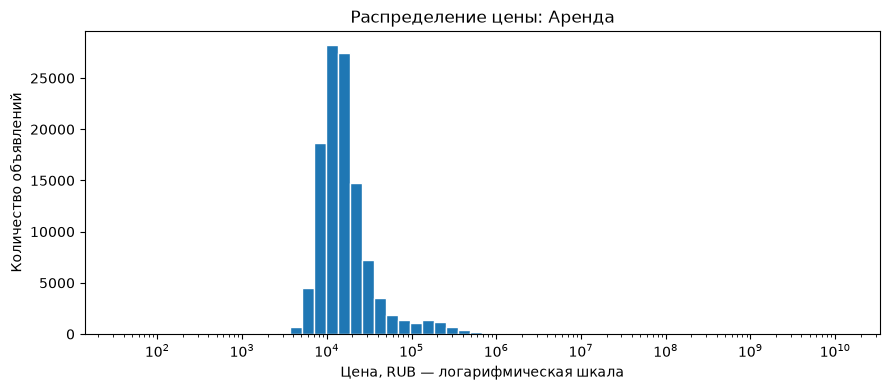

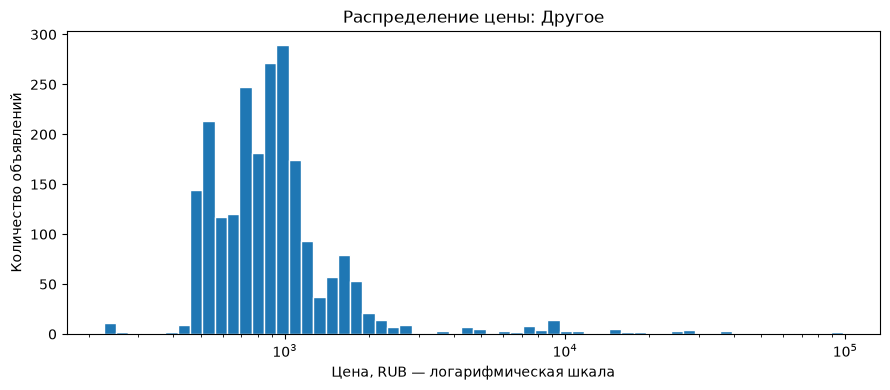

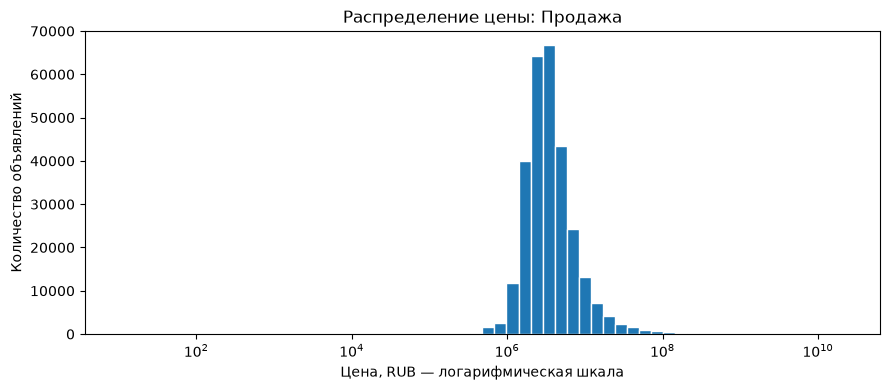

In [40]:
for listing_type, group in viz_df.groupby("listing_type"):
    prices = group[target]
    bins = np.geomspace(prices.min(), prices.max(), 61)

    plt.figure(figsize=(9, 4))
    plt.hist(prices, bins=bins, edgecolor="white")
    plt.xscale("log")
    plt.xlabel("Цена, RUB — логарифмическая шкала")
    plt.ylabel("Количество объявлений")
    plt.title(f"Распределение цены: {listing_type}")
    plt.tight_layout()
    plt.show()


Для всех трёх типов объявлений - аренда, продажа и другое - распределение цен сильно смещено вправо.

- Основная масса объектов находится в относительно узком диапазоне цен.
- При этом присутствуют отдельные объекты с очень высокой стоимостью, поэтому распределение имеет длинный правый хвост.
- Для аренды основная концентрация находится примерно около сотен–тысяч рублей по отображаемой шкале, а для продажи — около миллионов рублей.
- Поэтому средняя цена может заметно отличаться от медианной из-за дорогих объектов.

Продажа — самая массовая и дорогая группа; аренда дешевле, а категория «Другое» малочисленна и требует осторожной интерпретации.


#### Распределение площади

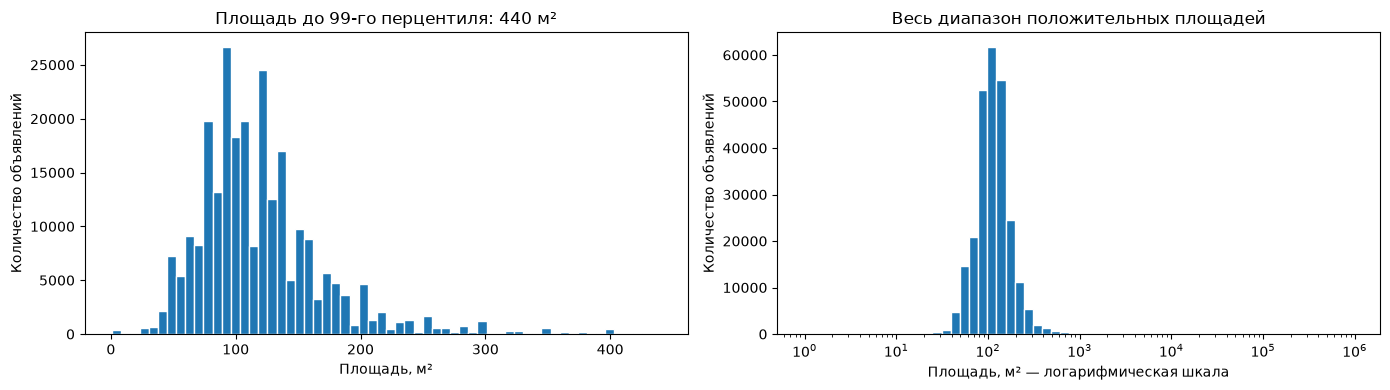

На левом графике не показаны значения выше порога: 2559


In [41]:
# Для площади берём весь набор, включая объявления без цены.
areas = df_prices["size"].dropna()
areas = areas[areas > 0]

limit = areas.quantile(0.99)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Основная часть распределения.
# Большие площади не заменяются порогом.
axes[0].hist(
    areas[areas <= limit],
    bins=60,
    edgecolor="white"
)
axes[0].set_title(f"Площадь до 99-го перцентиля: {limit:,.0f} м²")
axes[0].set_xlabel("Площадь, м²")
axes[0].set_ylabel("Количество объявлений")

# Весь диапазон положительных площадей.
bins = np.geomspace(areas.min(), areas.max(), 61)

axes[1].hist(areas, bins=bins, edgecolor="white")
axes[1].set_xscale("log")
axes[1].set_title("Весь диапазон положительных площадей")
axes[1].set_xlabel("Площадь, м² — логарифмическая шкала")
axes[1].set_ylabel("Количество объявлений")

plt.tight_layout()
plt.show()

print(
    "На левом графике не показаны значения выше порога:",
    int((areas > limit).sum())
)

- Слева показана основная часть данных, справа - весь диапазон.
- Большинство объектов имеют площадь примерно до 150–200 м², а основная концентрация находится примерно в районе 50–150 м².

#### Количество комнат

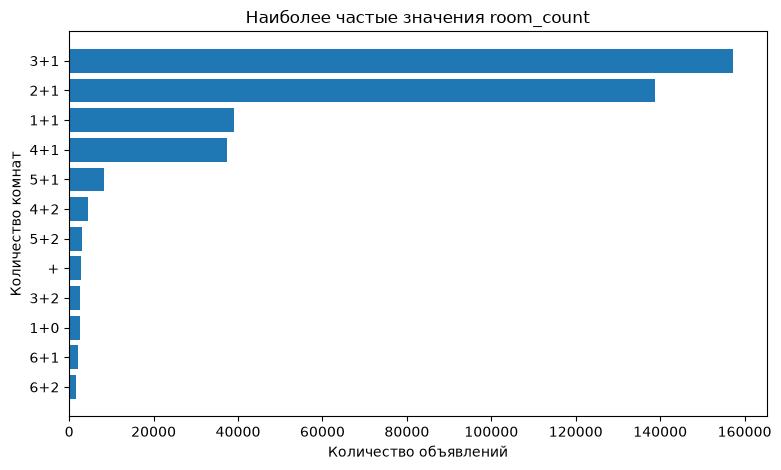

In [42]:
room_counts = df['room_count'].value_counts().head(12).sort_values()

plt.figure(figsize=(9,5))
plt.barh(room_counts.index.astype(str), room_counts.values)
plt.xlabel('Количество объявлений')
plt.ylabel('Количество комнат')
plt.title('Наиболее частые значения room_count')
plt.show()

**Вывод:** наиболее массовые типы квартир представлены несколькими повторяющимися форматами комнат.

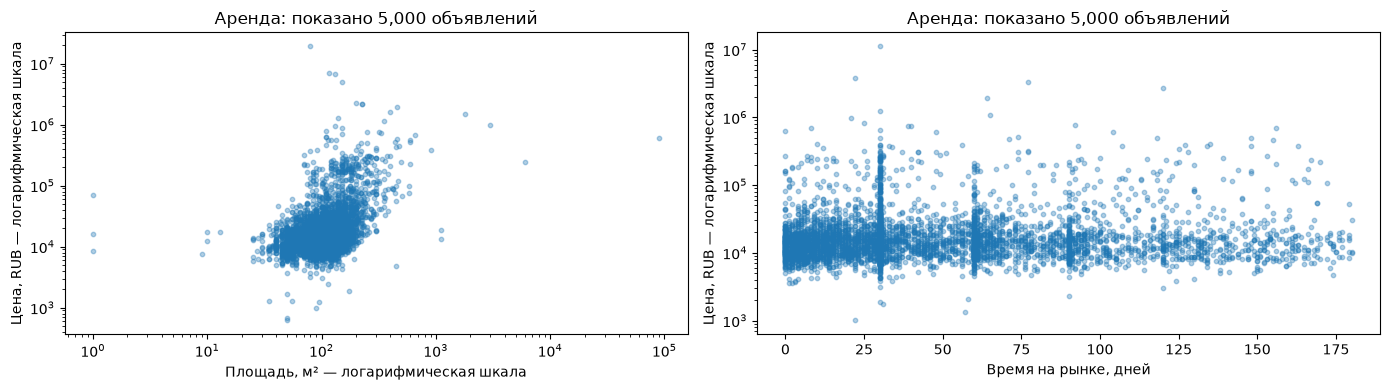

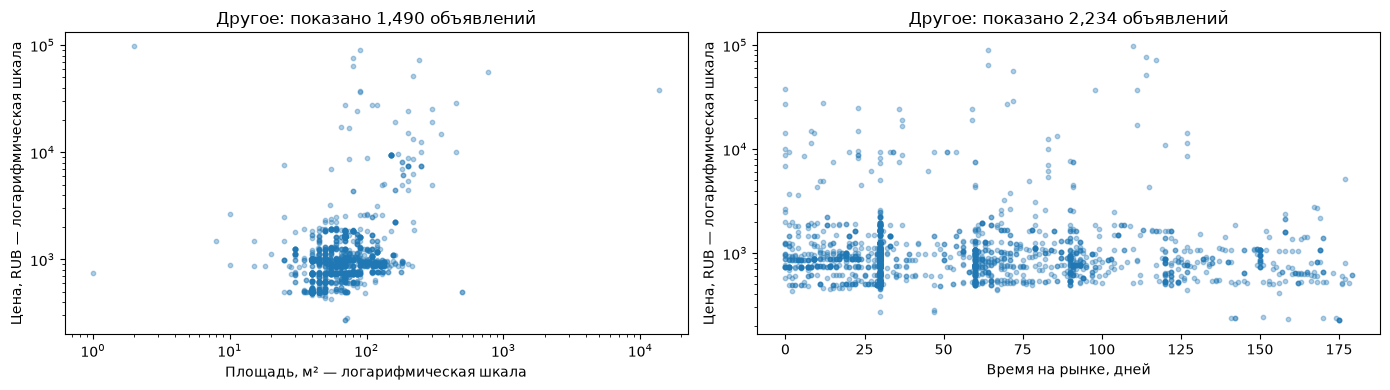

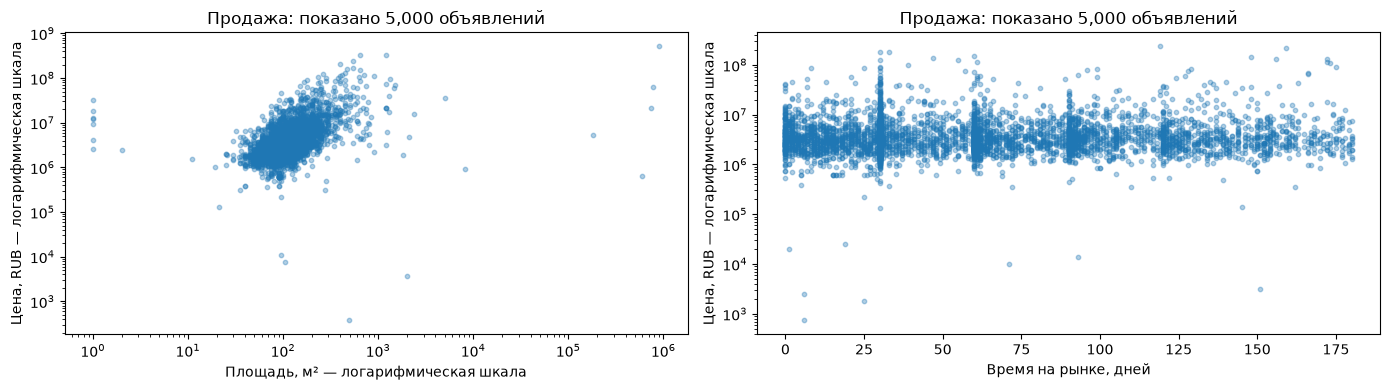

In [43]:
for listing_type, group in viz_df.groupby("listing_type"):
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    settings = [
        ("size", "Площадь, м² — логарифмическая шкала"),
        ("tom", "Время на рынке, дней"),
    ]

    for ax, (feature, label) in zip(axes, settings):
        points = group[[feature, target]].dropna()
        if feature == "size":
            points = points.loc[points["size"].gt(0)]

        points = points.sample(n=min(5000, len(points)), random_state=42)
        ax.scatter(points[feature], points[target], s=10, alpha=0.35)
        ax.set_yscale("log")
        if feature == "size":
            ax.set_xscale("log")

        ax.set_xlabel(label)
        ax.set_ylabel("Цена, RUB — логарифмическая шкала")
        ax.set_title(f"{listing_type}: показано {len(points):,} объявлений")

    plt.tight_layout()
    plt.show()


На точечных графиках видно достаточно выраженное облако точек: при увеличении площади цена в целом также увеличивается.

Особенно хорошо эта зависимость заметна для объявлений «Продажа».

При этом точки сильно разбросаны, то есть объекты одинаковой площади могут иметь существенно разные цены.

#### Boxplot цены по крупнейшим подтипам недвижимости

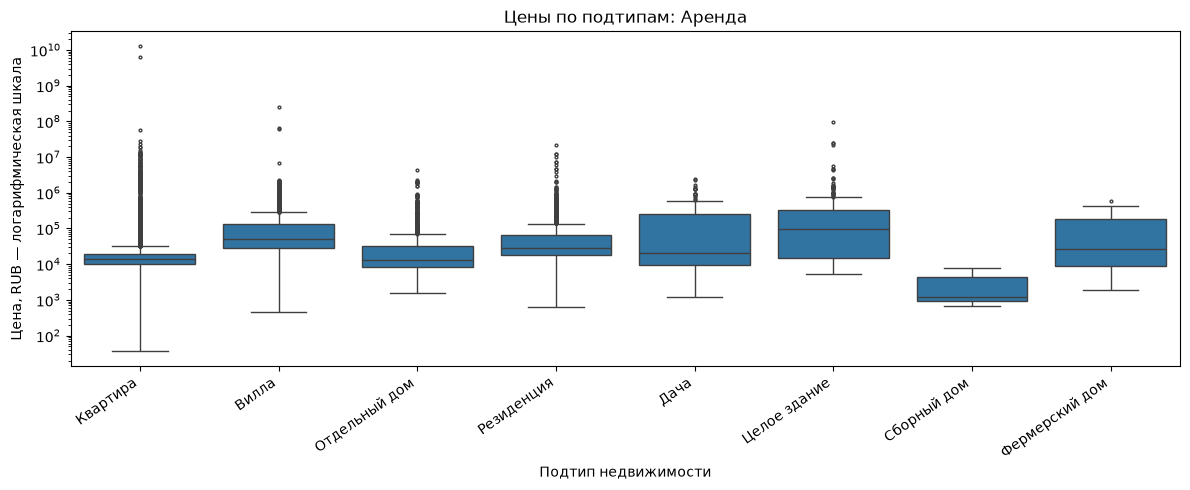

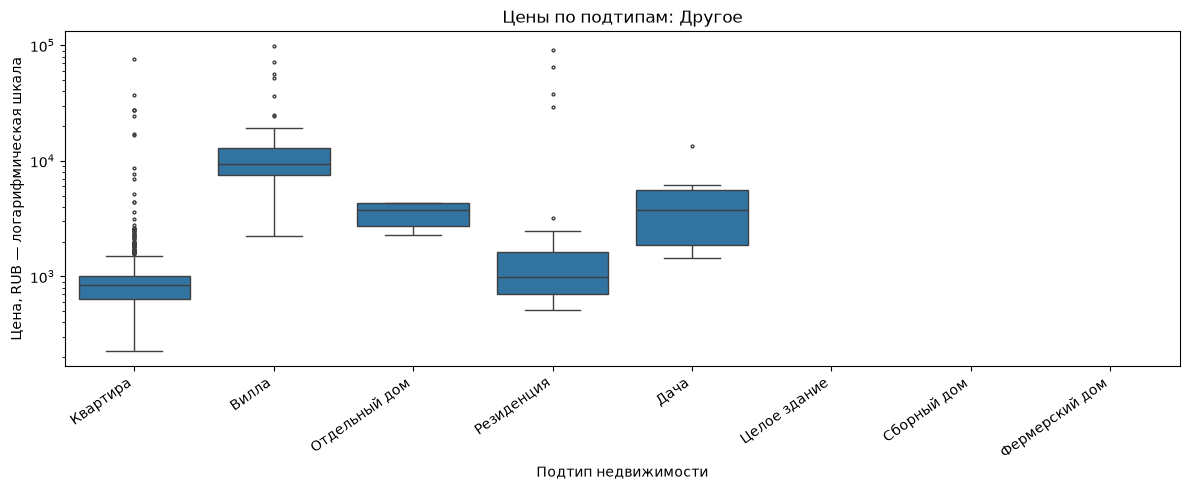

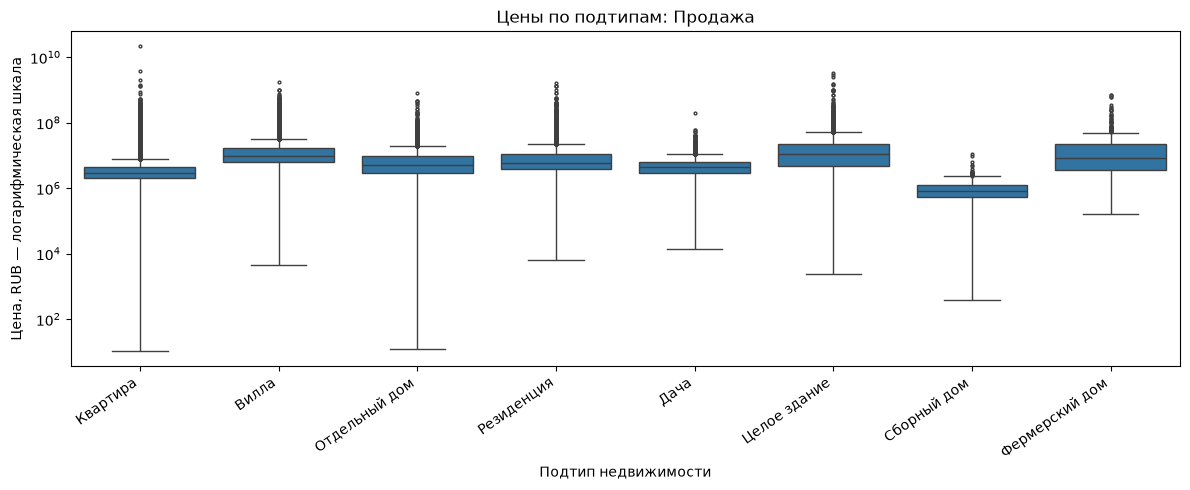

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns

# Одинаковый набор подтипов для сравнения между группами.
top_subtypes = (
    viz_df["sub_type"]
    .value_counts()
    .head(8)
    .index
)

for listing_type, group in viz_df.groupby("listing_type"):
    box_data = group.loc[
        group["sub_type"].isin(top_subtypes)
    ]

    plt.figure(figsize=(12, 5))

    sns.boxplot(
        data=box_data,
        x="sub_type",
        y=target,
        order=top_subtypes,
        showfliers=True,
        fliersize=2
    )

    plt.yscale("log")
    plt.xticks(rotation=35, ha="right")
    plt.xlabel("Подтип недвижимости")
    plt.ylabel("Цена, RUB — логарифмическая шкала")
    plt.title(f"Цены по подтипам: {listing_type}")

    plt.tight_layout()
    plt.show()

Тип объявления и подтип недвижимости заметно связаны с уровнем цены. Выбросы
есть во всех группах, поэтому далее используются устойчивое масштабирование и
логарифмическое преобразование.


Boxplot показывает заметное различие цен между подтипами недвижимости.

Например, виллы и целые здания имеют более высокие уровни цен, тогда как съёмные/более компактные типы жилья находятся ниже.

Также практически для всех подтипов присутствует большое количество выбросов.

Вывод: тип недвижимости существенно связан с уровнем цены. Поэтому категориальный признак подтипа недвижимости имеет смысл учитывать при построении модели прогнозирования.

Boxplot рассчитывается по исходным пересчитанным значениям, выбросы показываются.

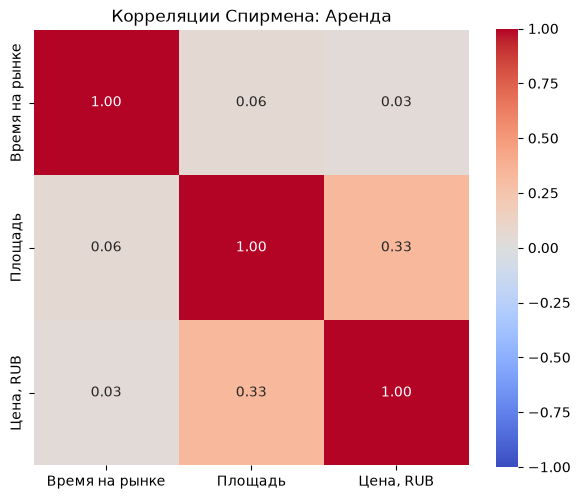

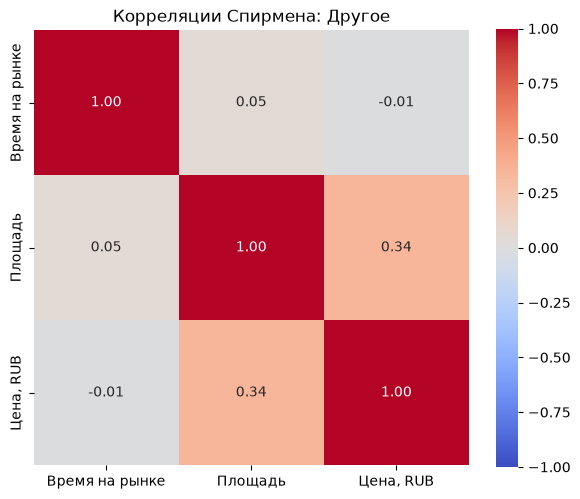

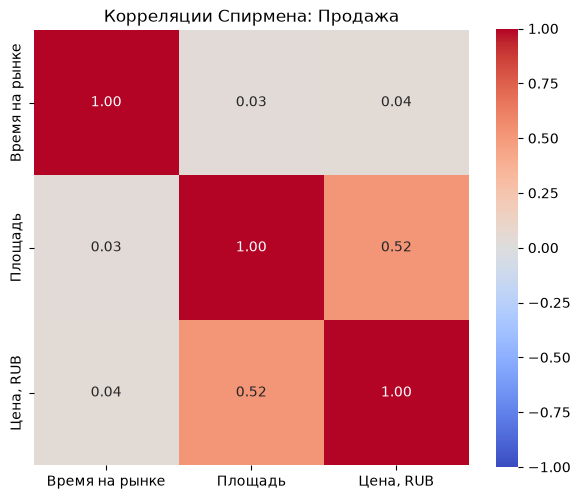

In [45]:
column_labels = {
    "tom": "Время на рынке",
    "size": "Площадь",
    target: "Цена, RUB",
}

for listing_type, group in viz_df.groupby("listing_type"):
    corr = (
        group[["tom", "size", target]]
        .rename(columns=column_labels)
        .corr(method="spearman")
    )

    plt.figure(figsize=(6, 5))
    sns.heatmap(
        corr, annot=True, cmap="coolwarm", fmt=".2f",
        vmin=-1, vmax=1, center=0, square=True,
    )
    plt.title(f"Корреляции Спирмена: {listing_type}")
    plt.tight_layout()
    plt.show()


Вывод: площадь является одним из наиболее заметных числовых факторов, связанных с ценой, особенно для продаж. Время нахождения объявления на рынке в данном датасете практически не связано с ценой.

Здесь используются содержательные числовые характеристики и пересчитанная цена. Выбран коэффициент Спирмена: он оценивает монотонную связь и менее чувствителен к величине экстремальных значений. Корреляция показывает связь, но сама по себе не доказывает влияние одного признака на другой.

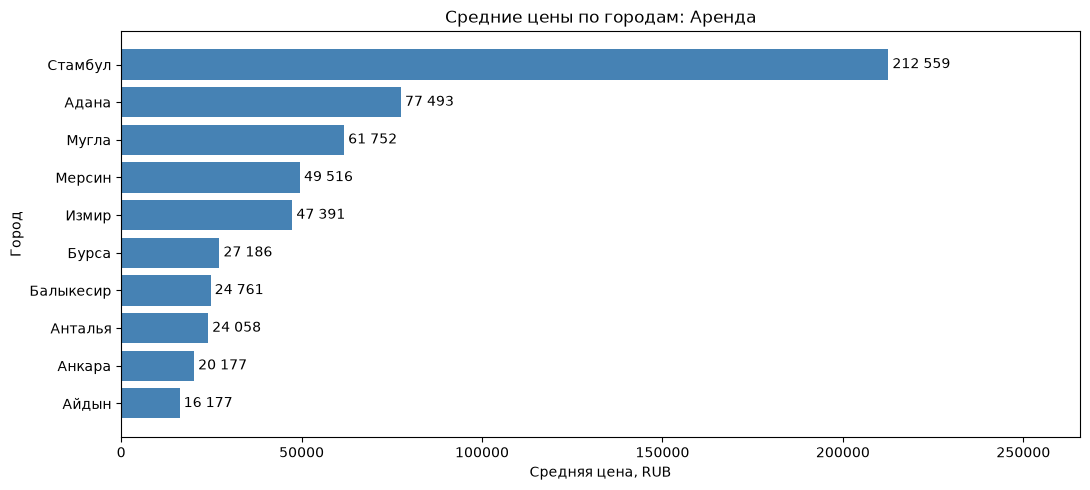

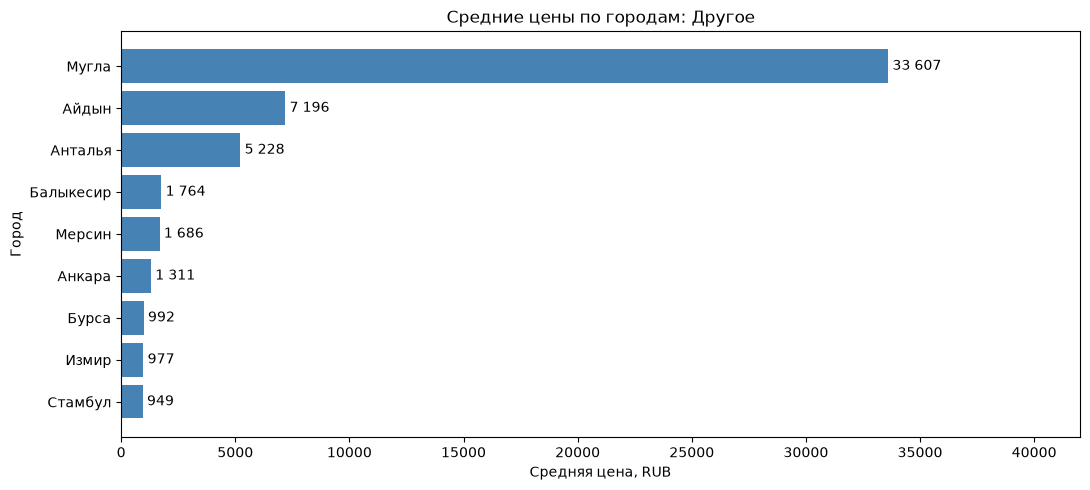

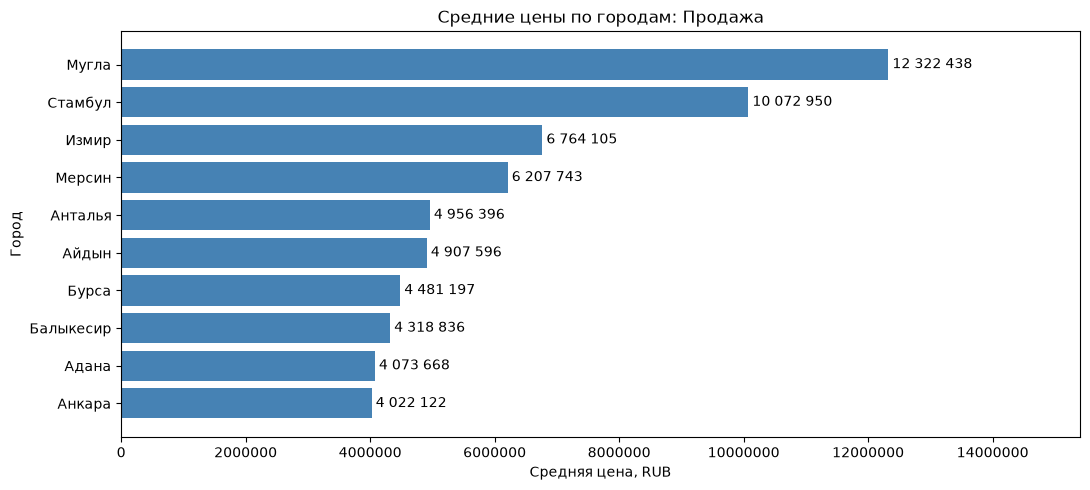

In [46]:
# Выбираем одни и те же города для всех типов объявлений.
top_cities = (
    viz_df["city"]
    .value_counts()
    .head(10)
    .index
)

for listing_type, group in viz_df.groupby("listing_type"):
    city_price = (
        group.loc[group["city"].isin(top_cities)]
        .groupby("city")[target]
        .mean()
        .sort_values()
    )

    if city_price.empty:
        continue

    fig, ax = plt.subplots(figsize=(11, 5))

    bars = ax.barh(
        city_price.index,
        city_price.values,
        color="steelblue"
    )

    # Подписываем значения, чтобы их было удобно читать.
    ax.bar_label(
        bars,
        labels=[
            f"{value:,.0f}".replace(",", " ")
            for value in city_price.values
        ],
        padding=3
    )

    ax.margins(x=0.25)
    ax.ticklabel_format(axis="x", style="plain", useOffset=False)
    ax.set_xlabel("Средняя цена, RUB")
    ax.set_ylabel("Город")
    ax.set_title(f"Средние цены по городам: {listing_type}")

    plt.tight_layout()
    plt.show()

Вывод: местоположение объекта является очень важным фактором стоимости. Средняя цена существенно различается между городами, причём характер различий зависит от типа объявления.

### 1.4 Анализ пропусков и аномалий

In [52]:
df.isna().sum()

id                        0
type                      0
sub_type                  0
start_date                0
end_date             137189
listing_type              0
tom                       0
building_age          27390
total_floor_count     28021
floor_no              35296
room_count                0
size                 146006
address                   0
heating_type          27970
price                   715
price_currency          715
city                      0
district                  0
dtype: int64

In [53]:
missing_table = pd.DataFrame({
    "Количество пропусков": df.isna().sum(),
    "Доля пропусков, %": (df.isna().mean() * 100).round(2)
}).sort_values("Количество пропусков", ascending=False)

display(missing_table)

,Количество пропусков,"Доля пропусков, %"
size,146006,36.19
end_date,137189,34.00
floor_no,35296,8.75
total_floor_count,28021,6.94
heating_type,27970,6.93
building_age,27390,6.79
price,715,0.18
price_currency,715,0.18
type,0,0.00
id,0,0.00


Таблица содержит количество и долю пропусков по каждому актуальному столбцу.
Наибольшая доля отсутствующих значений наблюдается у площади и даты завершения
объявления; также пропуски есть в этажности, этаже, отоплении и возрасте здания.
`furnished` был удалён раньше как полностью пустой признак.


Вывод: пропуски особенно важны для признаков площади, возраста здания, этажности и отопления. Столбец **furnished** не содержит полезной информации, если он полностью пуст.

### Проверка дубликатов

In [54]:
print('Количество полных дубликатов:', df.duplicated().sum())

Количество полных дубликатов: 0


In [55]:
comparison_cols = [
    col for col in df.columns
    if col != "id"
]

print(
    "Повторных строк без учёта id:",
    df.duplicated(subset=comparison_cols).sum()
)

Повторных строк без учёта id: 11559


Полных дубликатов с учётом всех столбцов не обнаружено. Однако без учёта уникального id найдено 11 559 повторных строк. Эти совпадения требуют дополнительной проверки перед решением об удалении.

### Проверка логических аномалий

In [56]:
def floor_count_for_check(value):
    if pd.isna(value):
        return np.nan
    value = str(value).strip()
    if value.endswith("+"):
        return float(value[:-1])
    if "-" in value:
        left, right = value.split("-", maxsplit=1)
        if left.replace(".", "", 1).isdigit() and right.replace(".", "", 1).isdigit():
            return float(right)
    return pd.to_numeric(value, errors="coerce")


floor_num = pd.to_numeric(df["floor_no"], errors="coerce")
total_floors_num = df["total_floor_count"].map(floor_count_for_check)

anomaly_counts = pd.Series({
    "Отрицательная цена, RUB": (df_prices[target] < 0).sum(),
    "Нулевая цена, RUB": (df_prices[target] == 0).sum(),
    "Нулевая или отрицательная площадь": (df["size"] <= 0).sum(),
    "Площадь меньше 10 м²": (df["size"] < 10).sum(),
    "Площадь больше 10 000 м²": (df["size"] > 10000).sum(),
    "Количество комнат указано как +": df["room_count"].eq("+").sum(),
    "Этаж превышает этажность здания": (floor_num > total_floors_num).sum(),
}, name="Количество строк")

display(anomaly_counts)


Отрицательная цена, RUB                 1
Нулевая цена, RUB                      44
Нулевая или отрицательная площадь       0
Площадь меньше 10 м²                  389
Площадь больше 10 000 м²              148
Количество комнат указано как +      2898
Этаж превышает этажность здания      1387
Name: Количество строк, dtype: int64

Неположительные цены исключаются перед моделированием. Площадь меньше 10 м² или
больше 10 000 м² рассматривается как явно аномальная и переводится в пропуск,
но строка сохраняется: площадь затем заполняется медианой только по обучающей
части. Крупные положительные цены без подтверждения не удаляются; их влияние
уменьшается логарифмированием цели, а MAE, RMSE, MAPE и R² рассматриваются вместе.


### 1.5 Промежуточные выводы и гипотезы

#### Основные выводы и гипотезы

1. **Большая площадь связана с более высокой ценой.** Это подтверждается
   scatter-графиками и положительными корреляциями Спирмена.
2. **Цена различается между подтипами недвижимости.** Boxplot показывает
   разные уровни и разброс стоимости по категориям объектов.
3. **Местоположение связано с уровнем цены.** Средняя стоимость заметно
   различается между городами, хотя часть различий объясняется составом объектов.
4. **Время на рынке связано с ценой слабее площади и местоположения.**
   Наблюдаемая корреляция мала и не подтверждает сильную монотонную зависимость.

Перед моделированием необходимо обработать пропуски, исключить недопустимые
значения и не допустить попадания цены или послепродажных характеристик во
входные признаки. Корреляции описывают связи, но не доказывают причинность.


### *Этап 2. Предварительная обработка данных*

### 2.1 Работа с пропусками

In [57]:
from sklearn.impute import SimpleImputer

In [58]:
# Целевая переменная — цена в рублях
target = "price_rub"

In [59]:
# Берём все типы объявлений
df_stage2 = df_prices.copy()

In [60]:
# Учитываем скрытый пропуск в количестве комнат
df_stage2["room_count"] = (
    df_stage2["room_count"].replace("+", pd.NA)
)

In [61]:
# Исключаем строки, в которых неизвестна целевая цена
missing_target_count = df_stage2[target].isna().sum()

df_stage2 = (
    df_stage2
    .dropna(subset=[target])
    .copy()
)

Для обработки пропусков создана отдельная рабочая таблица со всеми типами
объявлений и известной целевой ценой в рублях. Строки без target исключены:
заполнение целевой переменной создало бы искусственные ответы для модели.
Полностью пустой признак `furnished` удалён ранее.


In [62]:
# Заполняем пропуски в категориальных характеристиках
categorical_missing_cols = [
    "building_age",
    "total_floor_count",
    "floor_no",
    "heating_type",
    "room_count"
]

df_stage2[categorical_missing_cols] = (
    df_stage2[categorical_missing_cols]
    .fillna("Не указано")
)

Пропуски в категориальных характеристиках заменены значением «Не указано». Значение «+» в room_count также отнесено к отсутствующей информации, поскольку оно не позволяет определить количество комнат.

На этом шаге отсутствие категориальной информации обозначено значением «Не указано», которое сохраняется в рабочей таблице df_clean.

При дальнейшем кодировании номинальных признаков это значение рассматривается как отдельная категория. Для порядковых признаков building_age и total_floor_count применяется другая схема: неизвестное значение заменяется наиболее частым известным рангом обучающей выборки, а отдельный индикатор сохраняет информацию о первоначальном пропуске. Все обучаемые параметры этой обработки определяются только по train.

In [63]:
# Подготавливаем обработчик пропусков площади
# Обучим его только на train после разбиения в пункте 2.6
size_imputer = SimpleImputer(strategy="median")

Для площади выбран метод заполнения медианой. Он позволяет сохранить строки с неизвестной площадью и уменьшает влияние экстремальных значений на величину заполнения. Медиана будет рассчитана только на обучающей выборке после разбиения данных в пункте 2.6.

In [64]:
# end_date не заполняем произвольными датами.

print( "Исключено строк без целевой цены:",int(missing_target_count))
print("Осталось строк:", len(df_stage2))
missing_after = pd.DataFrame({ "Количество пропусков": df_stage2.isna().sum(),"Доля пропусков, %": ( df_stage2.isna().mean() * 100 ).round(2)})

display( missing_after.loc[missing_after["Количество пропусков"] > 0 ])

Исключено строк без целевой цены: 715
Осталось строк: 402772


,Количество пропусков,"Доля пропусков, %"
end_date,136474,33.88
size,145392,36.10


Пропуски в end_date сохранены, поскольку неизвестную дату окончания объявления нельзя достоверно восстановить. Этот столбец не будет использоваться как входной признак модели, прогнозирующей цену нового объявления.

### 2.2 Обработка выбросов

In [65]:
df_clean = df_stage2.copy()

In [66]:
# Недопустимые цены: неположительные или бесконечные
inv_price = ((df_clean[target] <= 0) | ~np.isfinite(df_clean[target]))

In [67]:
removed_price_count = int(inv_price.sum())

In [68]:
df_clean = df_clean.loc[~inv_price].copy()

In [69]:
# Явно невозможную площадь считаем неизвестной, но строку не удаляем.
# Медиану для заполнения Pipeline вычислит только на обучающей части.
inv_size = (
    df_clean["size"].notna()
    & (
        df_clean["size"].lt(10)
        | df_clean["size"].gt(10_000)
        | ~np.isfinite(df_clean["size"])
    )
)


In [70]:
inv_size_count = int(inv_size.sum())
df_clean.loc[inv_size, "size"] = np.nan


In [71]:
print("Исключено строк с недопустимой ценой:",removed_price_count)
print("Некорректных площадей заменено на пропуск:",inv_size_count)
print("Осталось строк:", len(df_clean))

display( df_clean["listing_type"].value_counts().sort_index().rename("Количество объявлений"))

Исключено строк с недопустимой ценой: 45
Некорректных площадей заменено на пропуск: 537
Осталось строк: 402727


listing_type
Аренда     114101
Другое       2234
Продажа    286392
Name: Количество объявлений, dtype: int64

Перед моделированием исключены только строки с неположительной или бесконечной
целевой ценой. Явно аномальная площадь не является основанием удалять всё
объявление: её значение заменено пропуском и будет обработано внутри Pipeline.
Актуальное количество затронутых строк выводится ячейкой выше.


In [72]:
#np.log1p(x) вычисляет ln(1 + x).
skewness_rows = []
# Сравниваем распределения отдельно по типам объявлений.
for listing_type, group in df_clean.groupby("listing_type"):
    for feature in [target, "size"]:
        values = group[feature].dropna()
        log_values = np.log1p(values)

        skewness_rows.append({
            "Тип объявления": listing_type,
            "Признак": feature,
            "Количество значений": len(values),
            "Асимметрия до": values.skew(),
            "Асимметрия после log1p": log_values.skew()})

skewness_comparison = pd.DataFrame(skewness_rows)
display(skewness_comparison.round(2))

,Тип объявления,Признак,Количество значений,Асимметрия до,Асимметрия после log1p
0,Аренда,price_rub,114101,269.42,2.20
1,Аренда,size,71103,43.07,0.41
2,Другое,price_rub,2234,13.23,2.93
3,Другое,size,1486,4.97,0.66
4,Продажа,price_rub,286392,280.44,0.64
5,Продажа,size,184249,29.46,1.14


Для целевой цены в рублях и площади проверено преобразование `log1p`.
Оно уменьшает влияние длинного правого хвоста, но не подтверждает корректность
каждой экстремальной записи. Преимущество преобразования оценивается только на
кросс-валидации.


Большие положительные цены сохранены: экстремальная величина сама по себе не
доказывает ошибку в объявлении. Для площади применены только широкие физически
обоснованные границы 10–10 000 м²; такие значения заменены пропусками без
удаления строк. Произвольная винсоризация целевой переменной не используется.

Логарифмирование уменьшает правую асимметрию цены и площади. Для площади оно
выполняется после медианного заполнения, причём параметры обработки обучаются
только на train и внутри каждого разбиения кросс-валидации.


### 2.3 Кодирование категориальных признаков

In [73]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

In [74]:
nominal_cols = [
    "listing_type",
    "sub_type",
    "heating_type",
    "floor_no",
    "room_count"
]

In [75]:
# Упорядоченные категории
ordinal_cols = [ "building_age","total_floor_count"]

In [76]:
# Признак с большим количеством категорий
address_cols = ["address"]

In [77]:
# Порядок возрастных категорий
age_order = [
    "0", "1", "2", "3", "4", "5",
    "6-10 arası",
    "11-15 arası",
    "16-20 arası",
    "21-25 arası",
    "26-30 arası",
    "31-35 arası",
    "36-40 arası",
    "40 ve üzeri"
]

In [78]:
# Порядок совпадает с категориями после перевода в ячейке подготовки данных.
floors_order = [
    "1", "2", "3", "4", "5", "6", "7", "8", "9", "10",
    "10-20", "20+",
]


In [79]:
print(df_clean["total_floor_count"].value_counts(dropna=False))

total_floor_count
4             83042
3             77930
5             70015
10-20         36504
2             27726
Не указано    27630
6             23190
10            12548
7             12277
8             11203
9              9024
20+            6676
1              4962
Name: count, dtype: int64


In [80]:
def floor_to_num(x):
    if pd.isna(x) or x == "Не указано":
        return np.nan
    x = str(x).strip()
    if x.endswith("+"):
        return 20                      # «20+» → 20
    if "-" in x:
        a, b = x.split("-")
        return (float(a) + float(b)) / 2
    return float(x)

df_clean["total_floor_num"] = df_clean["total_floor_count"].map(floor_to_num)

In [81]:
for column, order in zip(ordinal_cols, [age_order, floors_order]):
    unexpected = set(df_clean[column].dropna().unique()) - set(order) - {"Не указано"}
    if unexpected:
        raise ValueError(f"{column}: категории вне заданного порядка: {unexpected}")

categorical_cols = nominal_cols + ordinal_cols + address_cols
display(
    df_clean[categorical_cols]
    .nunique()
    .rename("Количество категорий")
    .to_frame()
)
print("Порядковые категории согласованы с данными")


,Количество категорий
listing_type,3
sub_type,12
heating_type,17
floor_no,36
room_count,37
building_age,15
total_floor_count,13
address,7833


Порядковые категории согласованы с данными


Для building_age и total_floor_count задано порядковое кодирование с явной последовательностью категорий. Полученные значения являются рангами и не интерпретируются как точный возраст или количество этажей. Для отсутствующих и неизвестных категорий предусмотрено заполнение наиболее частым известным рангом обучающей выборки с добавлением индикатора пропуска.

In [82]:
# Кодирование номинальных признаков
nominal_encoder = OneHotEncoder(handle_unknown="ignore",drop="first",sparse_output=True)

Для номинальных признаков выбран One-Hot Encoding. Значения listing_type рассматриваются как названия групп, а не количественные величины. Обозначения этажа кодируются номинально, поскольку среди них присутствуют текстовые категории, для которых не задан единый содержательный порядок. 

In [83]:
# Кодирование порядковых признаков
# и обработка отсутствующих/неизвестных категорий
ordinal_pipeline = Pipeline([
    ("encode",OrdinalEncoder(categories=[age_order, floors_order],handle_unknown="use_encoded_value",unknown_value=np.nan,dtype=np.float64)),
    ( "fill",SimpleImputer(strategy="most_frequent",add_indicator=True) )])

In [84]:
# Редкие адресные категории объединяются внутри кодера
address_encoder = OneHotEncoder(min_frequency=20,handle_unknown="infrequent_if_exist",drop="first",sparse_output=True)

Для address выбрано объединение категорий, встречающихся менее 20 раз в обучающей выборке, с последующим One-Hot Encoding. Это уменьшает размерность, но приводит к потере части различий между редкими адресами. Порог является начальной настройкой и может быть пересмотрен по результатам валидации.

In [85]:
# Объединяем обработку категориальных признаков
categorical_preprocessor = ColumnTransformer(
    transformers=[("nominal", nominal_encoder, nominal_cols),("ordinal", ordinal_pipeline, ordinal_cols),("address", address_encoder, address_cols)],
    remainder="drop",sparse_threshold=1.0)

In [86]:
print("Кодеры подготовлены, обучение будет выполнено на train в пункте 2.6.")

Кодеры подготовлены, обучение будет выполнено на train в пункте 2.6.


На данном шаге подготовлены правила и обработчик категориальных признаков. Его обучение будет выполнено только на train после разбиения данных. При кросс-валидации обработчик будет включён в Pipeline, чтобы обучаться внутри каждой обучающей части.

### 2.4 Работа с Feature Engineering

In [87]:
def add_model_features(data):
    result = data.copy()

    # Разбираем планировку вида "2+1".
    # Первое число - комнаты, второе — гостиные
    room_parts = (
        result["room_count"].astype("string").str.extract(r"^\s*(\d+)\s*\+\s*(\d+)\s*$").apply(pd.to_numeric, errors="coerce").astype(float))

    result["rooms_total"] = room_parts[0] + room_parts[1]
    result["living_rooms"] = room_parts[1]

    # Нераспознанную планировку и "0+0" считаем неизвестными
    inv_rooms = (room_parts.isna().any(axis=1) | result["rooms_total"].le(0))

    result.loc[inv_rooms,["rooms_total", "living_rooms"]] = np.nan

    # Один общий индикатор для двух признаков планировки
    result["rooms_missing"] = inv_rooms.astype("int8")

    # Время публикации относительно фиксированной даты
    start_dates = pd.to_datetime(result["start_date"],format="%m/%d/%y",errors="raise" )

    result["listing_time_days"] = (start_dates - pd.Timestamp("2018-01-01") ).dt.days
    return result


df_features = add_model_features(df_clean)
display(df_features[["room_count", "rooms_total", "living_rooms","rooms_missing", "start_date", "listing_time_days"]].head(10))

print("Неизвестная или неинформативная планировка:",int(df_features["rooms_missing"].sum()))

,room_count,rooms_total,living_rooms,rooms_missing,start_date,listing_time_days
0,2+1,3.0,1.0,0,12/10/18,343
1,1+0,1.0,0.0,0,2/13/19,408
2,2+1,3.0,1.0,0,10/9/18,281
3,6+1,7.0,1.0,0,9/10/18,252
4,2+1,3.0,1.0,0,12/10/18,343
5,1+1,2.0,1.0,0,11/9/18,312
6,3+1,4.0,1.0,0,1/4/19,368
7,4+1,5.0,1.0,0,10/3/18,275
8,3+1,4.0,1.0,0,2/16/19,411
9,2+2,4.0,2.0,0,12/26/18,359


Неизвестная или неинформативная планировка: 2308


Созданы четыре новых признака:

- `rooms_total` - общее количество комнат, включая гостиные;
- `living_rooms` - количество гостиных;
- `rooms_missing` - индикатор неизвестной или неинформативной планировки;
- `listing_time_days` - количество дней от фиксированной даты 01.01.2018 до начала публикации объявления.

Например, обозначение `2+1` преобразуется в три комнаты, включая одну гостиную. Первое число не интерпретируется как количество спален.

Нераспознанная планировка и обозначение `0+0` считаются неизвестными: числовые характеристики комнат получают пропуски, а индикатор - значение 1. Объявления сохраняются. Ноль гостиных в планировке `1+0` допустим.

Пропуски числовых характеристик комнат будут заполняться наиболее частыми значениями обучающей выборки после разбиения данных. Индикатор сохранит информацию о первоначальном отсутствии планировки.

Временной признак доступен при размещении объявления. Все новые признаки вычисляются без использования цены и без расчёта общих статистик по набору данных.

In [1]:
#определяем входы

In [88]:
numeric_cols = ["size","rooms_total","living_rooms","listing_time_days"]

In [89]:
binary_cols = ["rooms_missing"]

In [90]:
# room_count заменён числовыми характеристиками планировки
nominal_cols = ["listing_type","sub_type","heating_type","floor_no"]

In [91]:
# ordinal_cols и address_cols уже определены в пункте 2.3
categorical_cols = nominal_cols + ordinal_cols + address_cols

In [92]:
feature_cols = numeric_cols + binary_cols + categorical_cols

In [93]:
X = df_features[feature_cols].copy()
y = df_features[target].copy()

In [94]:
excluded_cols = [
    col for col in df_features.columns
    if col not in feature_cols and col != target]

In [95]:
# Проверяем соответствие строк и отсутствие цены среди входов.
assert X.index.equals(y.index)

In [96]:
assert not {"price", "price_try", "price_rub", "end_date", "tom"} & set(X.columns)

In [97]:
assert y.notna().all() and np.isfinite(y).all() and y.gt(0).all()

In [98]:
print("Размер X:", X.shape)
print("Размер y:", y.shape)
print("Не используются как входы модели:", excluded_cols)

display( X.isna().sum().rename("Количество пропусков"))

Размер X: (402727, 12)
Размер y: (402727,)
Не используются как входы модели: ['id', 'type', 'start_date', 'end_date', 'tom', 'room_count', 'price', 'price_currency', 'city', 'district', 'USD', 'GBP', 'TRY', 'RUB', 'EUR', 'price_try', 'total_floor_num']


size                 145889
rooms_total            2308
living_rooms           2308
listing_time_days         0
rooms_missing             0
listing_type              0
sub_type                  0
heating_type              0
floor_no                  0
building_age              0
total_floor_count         0
address                   0
Name: Количество пропусков, dtype: int64

Сформированы исходные входы `X` и целевая переменная `y = price_rub`.
Сохраняются объявления всех трёх типов; все обучаемые преобразования будут
оцениваться только на train и внутри разбиений кросс-валидации.


Для моделирования используются только характеристики, доступные в момент
публикации объявления.

Исключены `id`, константный `type`, исходная цена `price`, промежуточная
`price_try`, итоговая цель `price_rub`, дата завершения `end_date` и итоговое
время размещения `tom`. Планировка `room_count` заменена числовыми производными,
а `start_date` — числом дней от фиксированной даты. Цель `price_rub` хранится
отдельно в `y`, поэтому ценовые признаки не попадают во входы модели.


Теперь room_count отсутствует в списке категориальных входов. Поэтому нужно пересоздать обработчик с обновлённым списком

In [99]:
categorical_preprocessor = ColumnTransformer(transformers=[("nominal", nominal_encoder, nominal_cols),("ordinal", ordinal_pipeline, ordinal_cols),
        ("address", address_encoder, address_cols)], remainder="drop",sparse_threshold=1.0)

Категориальный обработчик обновлён, обучение - после разбиения

In [100]:
from statsmodels.stats.outliers_influence import (variance_inflation_factor)
from statsmodels.tools.tools import add_constant

VIF помогает выявить признаки, которые хорошо выражаются через другие входы линейной модели.

In [101]:
def calculate_vif(train_numeric):
    table = train_numeric.astype(float).copy()

    if not np.isfinite(table.to_numpy()).all():
        raise ValueError("Для VIF нужны числовые данные ""без пропусков и бесконечностей.")

    constant_cols = table.columns[table.nunique() <= 1].tolist()

    if constant_cols:
        raise ValueError(f"Сначала исключите константные признаки: {constant_cols}")

    # Свободный член нужен для вспомогательных регрессий
    design = add_constant(table, has_constant="add")

    return pd.DataFrame({
        "Признак": table.columns,
        "VIF": [
            variance_inflation_factor(
                design.to_numpy(), i + 1
            )
            for i in range(table.shape[1])]}).sort_values("VIF", ascending=False)

Функция VIF подготовлена. Расчёт выполним на train в пункте 2.6.

На этапе формирования входов исключены неинформативные признаки и очевидное дублирование исходных и производных характеристик.

Для дальнейшей проверки мультиколлинеарности подготовлена функция расчёта VIF. Она будет применена к числовой части обучающей выборки после заполнения пропусков и выбранных преобразований. В проверку будут включены используемые числовые признаки, порядковые коды и индикаторы пропусков. Целевая цена в расчёт не включается.

До получения результатов нельзя утверждать, что мультиколлинеарность полностью устранена. Высокие значения VIF потребуют рассмотрения зависимых признаков и обоснования дальнейшего отбора.

Дополнительное уменьшение размерности, например PCA, на данном шаге не применяется. Для адресов уже предусмотрено объединение редких категорий. Необходимость дальнейшего сокращения будет оцениваться после формирования обучающей матрицы с учётом её размера и результатов моделирования.

### 2.5 Масштабирование признаков

Подготовлены два варианта обработки: с масштабированием для линейных моделей и без масштабирования для моделей на основе деревьев.

Для линейных моделей выбрана следующая схема:

- size - Заполнение медианой - log1p - RobustScaler
- rooms_total, living_rooms - Заполнение наиболее частыми значениями  StandardScaler
- listing_time_days - StandardScaler
- Ранги возраста здания и этажности - Кодирование и заполнение пропусков  StandardScaler
- Индикаторы пропусков и One-Hot-признаки - Сохранение значений 0/1

Для площади выбран RobustScaler, поскольку его параметры рассчитываются по медиане и межквартильному размаху и меньше зависят от экстремальных значений. Само масштабирование не удаляет выбросы.

Количество комнат, дата публикации и порядковые коды приводятся к сопоставимому масштабу с помощью StandardScaler, использующего среднее и стандартное отклонение обучающей выборки.

MinMaxScaler в базовой схеме не используется: он зависит от крайних значений, из-за которых основная масса наблюдений может оказаться в узком интервале.

Для деревьев сохраняются заполнение пропусков, кодирование и выбранное преобразование площади, но шаги масштабирования отключаются. Логарифмирование площади остаётся вариантом для проверки при моделировании; его преимущество заранее не утверждается.

In [102]:
from sklearn.base import clone
from sklearn.preprocessing import (StandardScaler,RobustScaler,FunctionTransformer)

In [103]:
def make_preprocessor(scale_numeric=True):
    # Площадь: медиана - логарифмирование - масштабирование
    size_pipeline = Pipeline([
        ("impute", clone(size_imputer)),
        ("log", FunctionTransformer(np.log1p,feature_names_out="one-to-one")),
        ("scale",RobustScaler() if scale_numeric else "passthrough") ])

    # Числовые характеристики комнат
    # Общий индикатор пропуска уже есть в rooms_missing
    rooms_pipeline = Pipeline([
        ("impute", SimpleImputer(strategy="most_frequent")),
        ("scale",StandardScaler() if scale_numeric else "passthrough")])

    # Первые два выхода ordinal_pipeline — ранги
    # Остальные выходы — индикаторы пропусков
    if scale_numeric:
        ordinal_block = Pipeline([
            ("encode_fill", clone(ordinal_pipeline)),
            ("scale", ColumnTransformer(transformers=[ ("ranks", StandardScaler(), [0, 1])],remainder="passthrough",verbose_feature_names_out=False))])
    else:
        ordinal_block = clone(ordinal_pipeline)

    # Сохраняем настройки кодирования из предыдущих пунктов
    category_block = clone(categorical_preprocessor)
    category_block.set_params(ordinal=ordinal_block)

    # Объединяем обработку всех входных признаков
    return ColumnTransformer(
        transformers=[("size", size_pipeline, ["size"]),
            ("rooms", rooms_pipeline,
             ["rooms_total", "living_rooms"]),
            ("time",StandardScaler() if scale_numeric else "passthrough",
             ["listing_time_days"]),
            ("binary", "passthrough", binary_cols),
            ("categories", category_block, categorical_cols)],remainder="drop",sparse_threshold=1.0)

In [104]:
preprocessor_linear = make_preprocessor(scale_numeric=True)
preprocessor_tree = make_preprocessor(scale_numeric=False)

In [105]:
# Проверяем, что каждый входной столбец включён ровно один раз
used_cols = [col for _, _, columns in preprocessor_linear.transformers for col in columns]
assert len(used_cols) == len(set(used_cols))
assert set(used_cols) == set(X.columns)

print("Входных признаков до кодирования:", len(used_cols))
print("Обработка для линейных моделей и деревьев подготовлена")

Входных признаков до кодирования: 12
Обработка для линейных моделей и деревьев подготовлена


Созданы отдельные обработчики для линейных и древесных моделей. Заполнение
пропусков, преобразование площади, кодирование и масштабирование входят в
Pipeline и обучаются только на соответствующей обучающей части. Исходные `X`
и цель `y = price_rub` остаются непреобразованными до передачи в модель.


### 2.6 Разбиение данных

Группы определяем по исходному df, до заполнения пропусков и кодирования.

In [106]:
from sklearn.model_selection import GroupShuffleSplit, GroupKFold
from scipy.sparse import issparse

In [107]:
random_state = 42

In [2]:
#задается 10 полей для определения япотенциально повторных объявлений

In [108]:
# Исходные характеристики и дата начала объявления
# Цена и сведения об окончании публикации не используются
group_cols = [
    "sub_type",
    "start_date",
    "listing_type",
    "building_age",
    "total_floor_count",
    "floor_no",
    "room_count",
    "size",
    "address",
    "heating_type"]

In [109]:
raw_rows = df.loc[X.index, group_cols]

In [110]:
groups = (raw_rows.groupby(group_cols, dropna=False, sort=False).ngroup().rename("group_id"))

In [111]:
assert X.index.equals(y.index)
assert X.index.equals(groups.index)

Выполняем разбиение и проверяем отсутствие пересечений.

In [112]:
splitter = GroupShuffleSplit( n_splits=1,test_size=0.20,random_state=random_state)

In [113]:
train_pos, test_pos = next(splitter.split(X, groups=groups))

In [114]:
X_train = X.iloc[train_pos].copy()
X_test = X.iloc[test_pos].copy()

In [115]:
y_train = y.iloc[train_pos].copy()
y_test = y.iloc[test_pos].copy()

In [116]:
groups_train = groups.iloc[train_pos].copy()
groups_test = groups.iloc[test_pos].copy()

In [117]:
# Проверяем независимость выбранных групп
assert set(groups_train).isdisjoint(set(groups_test))
assert X_train.index.intersection(X_test.index).empty
assert len(X_train) + len(X_test) == len(X)
assert X_train.index.equals(y_train.index)
assert X_test.index.equals(y_test.index)

In [118]:
split_summary = pd.DataFrame({
    "Часть": ["train", "test"],
    "Количество строк": [len(X_train), len(X_test)],
    "Доля строк, %": [
        len(X_train) / len(X) * 100,
        len(X_test) / len(X) * 100],
    "Количество групп": [groups_train.nunique(),groups_test.nunique()]})

display(split_summary.round(2))

,Часть,Количество строк,"Доля строк, %",Количество групп
0,train,322372,80.05,238516
1,test,80355,19.95,59629


Пересечений групп между train и test нет.

In [119]:
# проверяем представленность типов объявлений
type_shares = pd.concat({
    "train, %": (X_train["listing_type"].value_counts(normalize=True) * 100),
    "test, %": (X_test["listing_type"].value_counts(normalize=True) * 100)}, axis=1).sort_index()
display(type_shares.round(2))

,"train, %","test, %"
listing_type,,
Аренда,28.27,28.58
Другое,0.55,0.56
Продажа,71.18,70.86


Выбрана схема train/test с долями примерно 80/20 и последующей кросс-валидацией внутри train. Для воспроизводимости зафиксирован random_state=42.

При разбиении учитываются группы записей с одинаковыми исходными характеристиками и датой начала объявления. Это позволяет оставить в одной части потенциальные повторные наблюдения, которые могут различаться ценой или длительностью публикации. Все строки сохраняются; группировка используется только для разделения данных.

Совпадение характеристик не доказывает, что записи относятся к одному физическому объекту. Принята консервативная схема, уменьшающая риск попадания похожих повторных наблюдений одновременно в обучение и проверку.

Получены 322 372 строки train и 80 355 строк test. Пересечений выбранных групп между частями нет. Все три типа объявлений представлены в обеих частях.

Тестовая выборка предназначена для итоговой оценки. Она не будет использоваться для выбора признаков, преобразований или гиперпараметров.

Подготавливаем кросс-валидацию внутри train :

In [120]:
cv = GroupKFold( n_splits=5,shuffle=True,random_state=random_state)

In [121]:
cv_rows = []
validation_seen = np.zeros(len(X_train), dtype=int)

In [122]:
for fold, (fit_pos, valid_pos) in enumerate(
    cv.split(X_train, groups=groups_train),
    start=1
):
    assert set(groups_train.iloc[fit_pos]).isdisjoint(
        set(groups_train.iloc[valid_pos]))

    validation_seen[valid_pos] += 1
    cv_rows.append({
        "Разбиение": fold,
        "Строк для обучения": len(fit_pos),
        "Строк для валидации": len(valid_pos)})

assert np.all(validation_seen == 1)
display(pd.DataFrame(cv_rows))

,Разбиение,Строк для обучения,Строк для валидации
0,1,257726,64646
1,2,257947,64425
2,3,257797,64575
3,4,257955,64417
4,5,258063,64309


Теперь можно выполнить отложенные заполнение пропусков, кодирование и масштабирование

In [123]:
# Копии для проверки предобработки и расчёта VIF
linear_check = clone(preprocessor_linear)
tree_check = clone(preprocessor_tree)

X_train_linear_check = linear_check.fit_transform(X_train)
X_test_linear_check = linear_check.transform(X_test)

X_train_tree_check = tree_check.fit_transform(X_train)
X_test_tree_check = tree_check.transform(X_test)

C:\Users\polin\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as the infrequent category.
  warnings.warn(msg, UserWarning)
C:\Users\polin\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as the infrequent category.
  warnings.warn(msg, UserWarning)


In [124]:
matrix_rows = []
for label, train_matrix, test_matrix in [
    ("Линейные модели",
     X_train_linear_check, X_test_linear_check),

    ("Деревья",
     X_train_tree_check, X_test_tree_check)
]:
    assert train_matrix.shape[0] == len(X_train)
    assert test_matrix.shape[0] == len(X_test)
    assert train_matrix.shape[1] == test_matrix.shape[1]
    for matrix in [train_matrix, test_matrix]:
        values = matrix.data if issparse(matrix) else matrix
        assert np.isfinite(values).all()
    matrix_rows.append({
        "Вариант": label,
        "Строк train": train_matrix.shape[0],
        "Строк test": test_matrix.shape[0],
        "Признаков после обработки": train_matrix.shape[1],
        "Разреженная матрица": issparse(train_matrix) })

display(pd.DataFrame(matrix_rows))
print("После обработки пропусков и бесконечных значений нет")

,Вариант,Строк train,Строк test,Признаков после обработки,Разреженная матрица
0,Линейные модели,322372,80355,2684,True
1,Деревья,322372,80355,2684,True


После обработки пропусков и бесконечных значений нет


Копии обработчиков обучены исключительно на train. По этой части рассчитаны значения для заполнения пропусков, параметры масштабирования и правила объединения редких категорий. К test применён только метод transform.

Проверены одинаковое количество выходных признаков для train и test, сохранение числа строк и отсутствие пропусков и бесконечных значений в преобразованных матрицах. Получено разреженное представление данных.

Эти матрицы используются для проверки предобработки и расчёта VIF. При подборе моделей кросс-валидация будет получать исходные X_train, y_train и groups_train. Обработчик будет находиться внутри Pipeline с моделью и обучаться заново на каждой обучающей части. Заранее преобразованная на всём train матрица не будет передаваться в кросс-валидацию.

In [125]:
feature_names = linear_check.get_feature_names_out()

In [126]:
vif_mask = np.array([
    name.startswith((
        "size__",
        "rooms__",
        "time__",
        "binary__",
        "categories__ordinal__"))
    for name in feature_names])

vif_values = X_train_linear_check[:, vif_mask]

In [127]:
if issparse(vif_values):
    vif_values = vif_values.toarray()

In [128]:
vif_data = pd.DataFrame(
    vif_values,
    columns=feature_names[vif_mask],
    index=X_train.index)
vif_table = calculate_vif(vif_data)

In [129]:
# Убираем технические префиксы для удобства чтения.
vif_table["Признак"] = ( vif_table["Признак"].str.split("__").str[-1])
display(vif_table.round(2))

,Признак,VIF
7,missingindicator_building_age,2.32
8,missingindicator_total_floor_count,2.25
1,rooms_total,2.06
0,size,1.69
2,living_rooms,1.34
5,building_age,1.09
6,total_floor_count,1.03
4,rooms_missing,1.02
3,listing_time_days,1.00


In [130]:
if vif_table["VIF"].lt(5).all():
    print("В проверенном числовом блоке все VIF ниже 5")
else:
    print(
        "Есть VIF не ниже 5: "
        "требуется рассмотрение зависимых признаков")

В проверенном числовом блоке все VIF ниже 5


VIF рассчитан только на обучающей выборке для числового блока обработчика.
Все полученные значения ниже выбранного порога 5, поэтому оснований исключать
эти признаки по данной диагностике нет. One-Hot-индикаторы в расчёт не включены,
и результат не означает отсутствия любых зависимостей между категориями.


### *Этап 3. Построение модели регрессии*

### 3.1 Требование: не менее 3 разных моделей

Для сравнения выбраны три модели разной природы:

- `Ridge` — регуляризованная линейная модель;
- `DecisionTreeRegressor` — одиночное дерево решений;
- `GradientBoostingRegressor` — ансамбль последовательных деревьев.

Целевая переменная — стоимость в рублях `price_rub`. Все три типа объявлений
участвуют в обучении, а `listing_type` используется как категориальный признак.


In [131]:
from time import perf_counter
import os
from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import (mean_absolute_error, mean_squared_error,mean_absolute_percentage_error, r2_score)

In [132]:
# Параметры моделей оставляем по умолчанию
# random_state фиксирует воспроизводимость
baseline_models = {
    "Ridge": Pipeline([("preprocess", clone(preprocessor_linear)),("model", Ridge())]),
    "DecisionTree": Pipeline([("preprocess", clone(preprocessor_tree)),("model", DecisionTreeRegressor(random_state=random_state))]),
    "GradientBoosting": Pipeline([("preprocess", clone(preprocessor_tree)),("model", GradientBoostingRegressor(random_state=random_state))])}

### 3.1.1 Базовое сравнение моделей


Сначала модели оцениваются с параметрами по умолчанию. Используется одна и та
же пятичастная групповая кросс-валидация внутри train. Предобработка находится
внутри Pipeline и заново обучается только на обучающей части каждого разбиения.

Основная метрика — MAE в рублях. Дополнительно рассчитываются RMSE, MAPE и R²,
а MAE на обучении используется для диагностики переобучения. Отложенный test
не участвует в выборе модели или гиперпараметров.


In [133]:
def regression_metrics(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAPE_%": 100 * mean_absolute_percentage_error(y_true, y_pred),
        "R2": r2_score(y_true, y_pred) }

In [134]:
# Одни и те же групповые разбиения для всех моделей
assert X_train.index.equals(y_train.index)
assert X_train.index.equals(groups_train.index)
assert np.isfinite(y_train).all() and y_train.gt(0).all()

In [135]:
cv_splits = list(cv.split(X_train, groups=groups_train))

In [136]:
fold_rows = []
baseline_oof = pd.DataFrame(index=X_train.index)
for model_name, template in baseline_models.items():
    oof = np.full(len(X_train), np.nan)
    seen = np.zeros(len(X_train), dtype=int)

    for fold, (fit_pos, valid_pos) in enumerate(cv_splits, start=1):
        print(f"{model_name}: начало разбиения {fold}/{len(cv_splits)}", flush=True)
        # Новый Pipeline для каждого разбиения
        model = clone(template)

        X_fit = X_train.iloc[fit_pos]
        X_valid = X_train.iloc[valid_pos]
        y_fit = y_train.iloc[fit_pos]
        y_valid = y_train.iloc[valid_pos]

        started = perf_counter()
        model.fit(X_fit, y_fit)
        fit_seconds = perf_counter() - started

        valid_pred = model.predict(X_valid)
        train_pred = model.predict(X_fit)

        assert np.isfinite(valid_pred).all()
        assert np.isfinite(train_pred).all()

        oof[valid_pos] = valid_pred
        seen[valid_pos] += 1

        fold_rows.append({
            "Модель": model_name,
            "Разбиение": fold,
            **regression_metrics(y_valid, valid_pred),
            "MAE_train": mean_absolute_error(y_fit, train_pred),
            "fit_seconds": fit_seconds})

        print(
            f"Обучение заняло {fit_seconds:.1f} с",flush=True)
        del model

    # Каждая строка должна получить ровно один
    # прогноз от модели, которая на ней не обучалась
    assert np.all(seen == 1) and np.isfinite(oof).all()
    baseline_oof[model_name] = oof

Ridge: начало разбиения 1/5


C:\Users\polin\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as the infrequent category.
  warnings.warn(msg, UserWarning)


Обучение заняло 5.5 с
Ridge: начало разбиения 2/5


C:\Users\polin\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as the infrequent category.
  warnings.warn(msg, UserWarning)


Обучение заняло 5.3 с
Ridge: начало разбиения 3/5


...

Обучение заняло 63.6 с
GradientBoosting: начало разбиения 4/5


C:\Users\polin\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as the infrequent category.
  warnings.warn(msg, UserWarning)


Обучение заняло 62.0 с
GradientBoosting: начало разбиения 5/5


C:\Users\polin\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as the infrequent category.
  warnings.warn(msg, UserWarning)


Обучение заняло 63.7 с


In [137]:
baseline_folds = pd.DataFrame(fold_rows)

In [138]:
# Общая таблица результатов
baseline_results = (
    baseline_folds.groupby("Модель", sort=False).agg(
        MAE_CV=("MAE", "mean"),
        MAE_CV_std=("MAE", "std"),
        RMSE_CV=("RMSE", "mean"),
        MAPE_CV_pct=("MAPE_%", "mean"),
        R2_CV=("R2", "mean"),
        MAE_train=("MAE_train", "mean"),
        fit_seconds_mean=("fit_seconds", "mean")).sort_values("MAE_CV"))
display(baseline_results.round(3))

,MAE_CV,MAE_CV_std,RMSE_CV,MAPE_CV_pct,R2_CV,MAE_train,fit_seconds_mean
Модель,,,,,,,
DecisionTree,2572287.159,282094.196,6.498263e+07,24030.091,-5.556,83654.783,381.353
GradientBoosting,2892301.734,121771.057,4.266790e+07,4075.377,0.024,2716494.477,62.980
Ridge,3909878.879,104023.507,4.192781e+07,11842.486,0.072,3833012.990,5.280


- `MAE_CV` — средняя абсолютная ошибка на валидации, RUB;
- `MAE_CV_std` — разброс MAE между разбиениями;
- `RMSE_CV` — ошибка в RUB, чувствительная к крупным промахам;
- `MAPE_CV_pct` — средняя относительная ошибка, %;
- `R2_CV` — доля объяснённой дисперсии;
- `MAE_train` — ошибка на обучающих частях;
- `fit_seconds_mean` — среднее время обучения одного разбиения.


In [139]:
# проверяем качество отдельно для типов объявлений
type_rows = []

for model_name in baseline_oof.columns:
    for listing_type in sorted(X_train["listing_type"].unique()):
        mask = X_train["listing_type"].eq(listing_type)
        pred = baseline_oof.loc[mask, model_name]

        type_rows.append({
            "Модель": model_name,
            "listing_type": listing_type,
            "Количество": int(mask.sum()),
            **regression_metrics(y_train.loc[mask], pred),
            "Отрицательных прогнозов, %": 100 * pred.lt(0).mean()})

baseline_by_type = pd.DataFrame(type_rows)
display(baseline_by_type.round(3))

,Модель,listing_type,Количество,MAE,RMSE,MAPE_%,R2,"Отрицательных прогнозов, %"
0,Ridge,Аренда,91134,4.323525e+06,4.320827e+07,26494.134,-6.100000e-02,68.969
1,Ridge,Другое,1784,5.667039e+06,1.249478e+07,634295.373,-5.694401e+06,80.549
2,Ridge,Продажа,229454,3.731718e+06,5.171991e+07,1183.240,4.300000e-02,4.126
3,DecisionTree,Аренда,91134,4.930341e+05,7.290399e+07,2559.304,-2.021000e+00,0.000
4,DecisionTree,Другое,1784,2.136568e+07,4.524508e+08,4068475.343,-7.466791e+09,0.000
5,DecisionTree,Продажа,229454,3.252435e+06,5.597238e+07,1162.122,-1.210000e-01,0.000
6,GradientBoosting,Аренда,91134,1.163244e+06,4.585519e+07,4774.628,-1.950000e-01,57.042
7,GradientBoosting,Другое,1784,2.941400e+06,2.042321e+07,372676.868,-1.521386e+07,81.558
8,GradientBoosting,Продажа,229454,3.578644e+06,5.150062e+07,934.176,5.100000e-02,0.007


В этой таблице метрики рассчитаны по объединённым проверочным прогнозам каждого типа, а не усреднены по разбиениям. Она нужна, чтобы хороший общий результат не скрывал большие ошибки в отдельной группе.

Базовые результаты используются как отправная точка. При интерпретации нужно
учитывать не только среднюю MAE, но и разрыв между train и CV, RMSE, R² и
качество отдельно по типам объявлений. Окончательный выбор до настройки
гиперпараметров и проверки на отложенном test не производится.


### 3.2 Обучение и выбор гиперпараметров

Для каждой модели выполняется `GridSearchCV` с той же пятичастной групповой
кросс-валидацией внутри train. Подбираются сила регуляризации Ridge, ограничения
сложности дерева, а также скорость обучения и глубина Gradient Boosting.

Дополнительно сравниваются два варианта цели: `price_rub` и `log(price_rub)`.
Для логарифмической цели прогноз возвращается в рубли обратным преобразованием
`exp`. Конфигурация выбирается по минимальной средней MAE в RUB; дополнительно
рассчитываются RMSE, MAPE и R². Отложенный test в подборе не используется.


In [140]:
from sklearn.compose import TransformedTargetRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer

In [141]:
scoring = {
    "MAE": "neg_mean_absolute_error",
    "RMSE": "neg_root_mean_squared_error",
    "MAPE": make_scorer(mean_absolute_percentage_error,greater_is_better=False),
    "R2": "r2"}

model_param_grids = {
    "Ridge": {"regressor__model__alpha": [0.1, 1.0, 10.0, 100.0]},
    "DecisionTree": {"regressor__model__max_depth": [8, 16],"regressor__model__min_samples_leaf": [10, 50]},
    "GradientBoosting": {"regressor__model__learning_rate": [0.05, 0.1],"regressor__model__max_depth": [2, 3] }
}

In [142]:
# функция поиска
def run_search(model_name):
    assert X_train.index.equals(y_train.index)
    assert X_train.index.equals(groups_train.index)
    assert np.isfinite(y_train).all() and y_train.gt(0).all()

    estimator = TransformedTargetRegressor(
        regressor=clone(baseline_models[model_name])
    )

    # Исходная цена и логарифм цены:
    # каждому преобразованию соответствует своё обратное.
    grid = [
        {
            **model_param_grids[model_name],
            "func": [None],
            "inverse_func": [None]
        },
        {
            **model_param_grids[model_name],
            "func": [np.log],
            "inverse_func": [np.exp]
        }
    ]

    search = GridSearchCV(
        estimator=estimator,
        param_grid=grid,
        scoring=scoring,
        refit="MAE",
        cv=cv,
        n_jobs=min(2, max(1, os.cpu_count() or 1)),
        pre_dispatch=1,
        return_train_score=True,
        error_score="raise",
        verbose=1
    )

    started = perf_counter()

    search.fit(
        X_train,
        y_train,
        groups=groups_train
    )

    print(
        f"{model_name}: поиск занял "
        f"{(perf_counter() - started) / 60:.1f} мин"
    )
    print(f"Лучшая MAE по CV: {-search.best_score_:,.2f} RUB")
    print("Лучшие параметры:", search.best_params_)

    return search

In [143]:
ridge_search = run_search("Ridge")

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Ridge: поиск занял 5.0 мин
Лучшая MAE по CV: 1,820,355.24 RUB
Лучшие параметры: {'func': <ufunc 'log'>, 'inverse_func': <ufunc 'exp'>, 'regressor__model__alpha': 0.1}


In [144]:
tree_search = run_search("DecisionTree")

Fitting 5 folds for each of 8 candidates, totalling 40 fits
DecisionTree: поиск занял 7.0 мин
Лучшая MAE по CV: 2,236,047.83 RUB
Лучшие параметры: {'func': <ufunc 'log'>, 'inverse_func': <ufunc 'exp'>, 'regressor__model__max_depth': 16, 'regressor__model__min_samples_leaf': 10}


In [146]:
boosting_search = run_search("GradientBoosting")

Fitting 5 folds for each of 8 candidates, totalling 40 fits
GradientBoosting: поиск занял 39.2 мин
Лучшая MAE по CV: 2,263,500.55 RUB
Лучшие параметры: {'func': <ufunc 'log'>, 'inverse_func': <ufunc 'exp'>, 'regressor__model__learning_rate': 0.1, 'regressor__model__max_depth': 3}


In [147]:
#собираем результаты
searches = {
    "Ridge": ridge_search,
    "DecisionTree": tree_search,
    "GradientBoosting": boosting_search
}

best_models = {
    name: search.best_estimator_
    for name, search in searches.items()
}

tuned_rows = []
parameter_rows = []

for name, search in searches.items():
    results = search.cv_results_
    best = search.best_index_

    target_scale = (
        f"log({target})"
        if search.best_estimator_.func is np.log
        else target
    )

    # test в cv_results_ означает валидацию внутри CV,
    # а не отложенную выборку X_test.
    fold_mae = [
        -results[f"split{i}_test_MAE"][best]
        for i in range(search.n_splits_)
    ]

    tuned_rows.append({
        "Модель": name,
        "Цель при обучении": target_scale,
        "MAE_CV": -results["mean_test_MAE"][best],
        "MAE_CV_std": np.std(fold_mae, ddof=1),
        "RMSE_CV": -results["mean_test_RMSE"][best],
        "MAPE_CV_pct": -100 * results["mean_test_MAPE"][best],
        "R2_CV": results["mean_test_R2"][best],
        "MAE_train": -results["mean_train_MAE"][best],
        "fit_seconds_mean": results["mean_fit_time"][best]
    })

    parameter_rows.append({
        "Модель": name,
        "Цель при обучении": target_scale,
        "Лучшие параметры": {
            key.replace("regressor__model__", ""): value
            for key, value in search.best_params_.items()
            if key.startswith("regressor__model__")
        }
    })

tuned_results = (
    pd.DataFrame(tuned_rows)
    .set_index("Модель")
    .sort_values("MAE_CV")
)

best_parameters = (
    pd.DataFrame(parameter_rows)
    .set_index("Модель")
)

display(tuned_results.round(3))
display(best_parameters)

,Цель при обучении,MAE_CV,MAE_CV_std,RMSE_CV,MAPE_CV_pct,R2_CV,MAE_train,fit_seconds_mean
Модель,,,,,,,,
Ridge,log(price_rub),1820355.243,158172.121,4.088637e+07,402.613,0.152,1784640.683,4.546
DecisionTree,log(price_rub),2236047.834,148148.821,4.181471e+07,516.818,0.085,1990051.650,14.532
GradientBoosting,log(price_rub),2263500.552,152224.012,4.222700e+07,431.150,0.055,2256532.784,65.567


,Цель при обучении,Лучшие параметры
Модель,,
Ridge,log(price_rub),{'alpha': 0.1}
DecisionTree,log(price_rub),"{'max_depth': 16, 'min_samples_leaf': 10}"
GradientBoosting,log(price_rub),"{'learning_rate': 0.1, 'max_depth': 3}"


In [148]:
# Сравниваем качество моделей до и после подбора гиперпараметров.


In [149]:
mae_comparison = pd.DataFrame({
    "MAE_baseline": baseline_results["MAE_CV"],
    "MAE_tuned": tuned_results["MAE_CV"]
})


In [150]:
mae_comparison["Улучшение MAE, %"] = (
    100
    * (
        mae_comparison["MAE_baseline"]
        - mae_comparison["MAE_tuned"]
    )
    / mae_comparison["MAE_baseline"]
)

In [151]:
display(
    mae_comparison
    .sort_values("MAE_tuned")
    .round(3)
)

,MAE_baseline,MAE_tuned,"Улучшение MAE, %"
Модель,,,
Ridge,3909878.879,1820355.243,53.442
DecisionTree,2572287.159,2236047.834,13.072
GradientBoosting,2892301.734,2263500.552,21.741


Таблица выше показывает изменение MAE после подбора параметров. Основной
кандидат определяется по средней MAE групповой CV, но окончательный выбор ниже
дополнительно учитывает устойчивость, скорость и интерпретируемость. Высокие
MAPE или низкий R² рассматриваются как ограничение практического применения.


### 3.3 Метрики качества

Для дополнительной диагностики выбранных конфигураций получены OOF-прогнозы: каждая строка прогнозируется моделью, которая обучалась без этой строки и её группы. Используются прежние пять групповых разбиений. Предобработка заново обучается внутри каждой обучающей части.

Гиперпараметры уже выбраны на этих данных, поэтому такие прогнозы используются для диагностики, а не как независимая итоговая оценка. Отложенная тестовая выборка сохраняется для финальной проверки.

MAE, RMSE, MAPE и R² рассчитываются по объединённым OOF-прогнозам: для всей обучающей выборки и отдельно для каждого типа объявления. Дополнительно проверяется наличие отрицательных и нулевых прогнозов.

Эти показатели могут отличаться от средних метрик по пяти разбиениям из пункта 3.2: здесь метрики заново вычисляются по всем объединённым прогнозам. Основным критерием предварительного сравнения моделей остаётся ранее выбранная средняя MAE кросс-валидации.

In [3]:
#для каждой конфигурации проходится те же пять разбиений обучая копию и получая по одному oof-прогнозу для каждой строки обучения

In [152]:
from sklearn.base import clone

assert X_train.index.equals(y_train.index)
assert X_train.index.equals(groups_train.index)
assert np.isfinite(y_train).all() and y_train.gt(0).all()

cv_splits = list(cv.split(X_train, groups=groups_train))

for fit_pos, valid_pos in cv_splits:
    assert set(groups_train.iloc[fit_pos]).isdisjoint(
        set(groups_train.iloc[valid_pos])
    )

# Инициализацию оставляем в одной ячейке с циклом
tuned_oof = pd.DataFrame(index=X_train.index)

for name, template in best_models.items():
    predictions = np.full(len(X_train), np.nan)
    seen = np.zeros(len(X_train), dtype=int)

    for fold, (fit_pos, valid_pos) in enumerate(cv_splits, start=1):
        print(
            f"{name}: разбиение {fold}/{len(cv_splits)}",
            flush=True
        )

        fold_model = clone(template)

        fold_model.fit(
            X_train.iloc[fit_pos],
            y_train.iloc[fit_pos]
        )

        pred = fold_model.predict(X_train.iloc[valid_pos])

        if not np.isfinite(pred).all():
            raise ValueError(
                f"{name}: получены пропуски или бесконечные прогнозы"
            )

        predictions[valid_pos] = pred
        seen[valid_pos] += 1

        del fold_model

    assert np.all(seen == 1) and np.isfinite(predictions).all()

    tuned_oof[name] = predictions

    print(
        f"{name}: все проверочные прогнозы получены",
        flush=True
    )

Ridge: разбиение 1/5
Ridge: разбиение 2/5


C:\Users\polin\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as the infrequent category.
  warnings.warn(msg, UserWarning)


Ridge: разбиение 3/5


C:\Users\polin\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as the infrequent category.
  warnings.warn(msg, UserWarning)


Ridge: разбиение 4/5


...

C:\Users\polin\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as the infrequent category.
  warnings.warn(msg, UserWarning)


GradientBoosting: разбиение 5/5


C:\Users\polin\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as the infrequent category.
  warnings.warn(msg, UserWarning)


GradientBoosting: все проверочные прогнозы получены


C:\Users\polin\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as the infrequent category.
  warnings.warn(msg, UserWarning)


In [153]:
def oof_metrics(y_true, y_pred):
    return {
        "Количество": len(y_true),
        **regression_metrics(y_true, y_pred),
        "Отрицательные прогнозы, %": 100 * np.mean(y_pred < 0),
        "Нулевые прогнозы, %": 100 * np.mean(y_pred == 0)
    }

In [1]:
needed = [
    "np", "pd", "perf_counter", "clone",
    "GridSearchCV", "TransformedTargetRegressor",
    "mean_absolute_percentage_error", "make_scorer",
    "X_train", "y_train", "groups_train", "cv",
    "baseline_models", "scoring", "model_param_grids",
    "run_search",
    "ridge_search", "tree_search", "boosting_search",
    "searches", "best_models",
    "tuned_oof", "oof_metrics",
]
for n in needed:
    obj = globals().get(n, None)

In [155]:
overall_rows = []
type_rows_tuned = []

for name in tuned_oof.columns:
    overall_rows.append({
        "Модель": name,
        **oof_metrics(y_train, tuned_oof[name]) })

    for listing_type in sorted(X_train["listing_type"].unique()):
        mask = X_train["listing_type"].eq(listing_type)
        type_rows_tuned.append({
            "Модель": name,
            "listing_type": listing_type,
            **oof_metrics(
                y_train.loc[mask],
                tuned_oof.loc[mask, name])})

tuned_oof_results = (pd.DataFrame(overall_rows).set_index("Модель"))
tuned_by_type = pd.DataFrame(type_rows_tuned)

display(tuned_oof_results.round(3))
display(tuned_by_type.round(3))

,Количество,MAE,RMSE,MAPE_%,R2,"Отрицательные прогнозы, %","Нулевые прогнозы, %"
Модель,,,,,,,
Ridge,322372,1819584.206,4.873134e+07,402.890,0.048,0.0,0.0
DecisionTree,322372,2235886.265,4.925156e+07,516.950,0.027,0.0,0.0
GradientBoosting,322372,2263338.174,4.951195e+07,431.184,0.017,0.0,0.0


,Модель,listing_type,Количество,MAE,RMSE,MAPE_%,R2,"Отрицательные прогнозы, %","Нулевые прогнозы, %"
0,Ridge,Аренда,91134,169246.749,4.194429e+07,36.230,-0.000,0.0,0.0
1,Ridge,Другое,1784,927.671,4.851340e+03,46.828,0.142,0.0,0.0
2,Ridge,Продажа,229454,2489201.372,5.135794e+07,551.287,0.056,0.0,0.0
3,DecisionTree,Аренда,91134,171378.828,4.194426e+07,51.989,-0.000,0.0,0.0
4,DecisionTree,Другое,1784,745.073,4.920853e+03,26.152,0.117,0.0,0.0
5,DecisionTree,Продажа,229454,3073240.648,5.205048e+07,705.439,0.031,0.0,0.0
6,GradientBoosting,Аренда,91134,171486.051,4.194428e+07,47.966,-0.000,0.0,0.0
7,GradientBoosting,Другое,1784,947.914,4.788989e+03,63.776,0.163,0.0,0.0
8,GradientBoosting,Продажа,229454,3111765.116,5.239641e+07,586.247,0.018,0.0,0.0


OOF-прогнозы дают дополнительную диагностику настроенных моделей на всём train:
каждая строка прогнозируется моделью, которая на ней и её группе не обучалась.
Качество рассматривается как в целом, так и отдельно по типам объявлений.
Независимой итоговой оценкой остаётся только отложенная тестовая выборка.


### 3.4 Сравнение моделей

Базовые и настроенные модели сравниваются по средним метрикам одинаковых групповых разбиений кросс-валидации. Для обеих версий используется один способ агрегирования результатов.

Для предварительного лидера по средней CV-MAE дополнительно строятся графики «фактическая цена - прогноз» и графики остатков отдельно по типам объявлений. Они используют диагностические OOF-прогнозы выбранной конфигурации.

Остаток определяется как фактическая цена минус прогноз. Положительный остаток означает недооценку цены, отрицательный - переоценку.

In [156]:
# Средние метрики по разбиениям:
# одинаковая агрегация до и после подбора
metric_cols = [
    "MAE_CV",
    "RMSE_CV",
    "MAPE_CV_pct",
    "R2_CV"
]

comparison_cv = pd.concat(
    {
        "Базовые": baseline_results[metric_cols],
        "После подбора": tuned_results[metric_cols]
    },
    names=["Вариант", "Модель"]
)

In [157]:
display(comparison_cv.round(3))

MAE_CV       RMSE_CV  MAPE_CV_pct  R2_CV
Вариант       Модель                                                         
Базовые       DecisionTree      2572287.159  6.498263e+07    24030.091 -5.556
              GradientBoosting  2892301.734  4.266790e+07     4075.377  0.024
              Ridge             3909878.879  4.192781e+07    11842.486  0.072
После подбора Ridge             1820355.243  4.088637e+07      402.613  0.152
              DecisionTree      2236047.834  4.181471e+07      516.818  0.085
              GradientBoosting  2263500.552  4.222700e+07      431.150  0.055

In [158]:
model_order = tuned_results.index.tolist()

In [159]:
plot_settings = [
    ("MAE_CV", "MAE, тыс. RUB — меньше лучше", 1000),
    ("RMSE_CV", "RMSE, млн RUB — меньше лучше", 1_000_000),
    ("MAPE_CV_pct", "MAPE, % — меньше лучше", 1),
    ("R2_CV", "R² — больше лучше", 1)
]

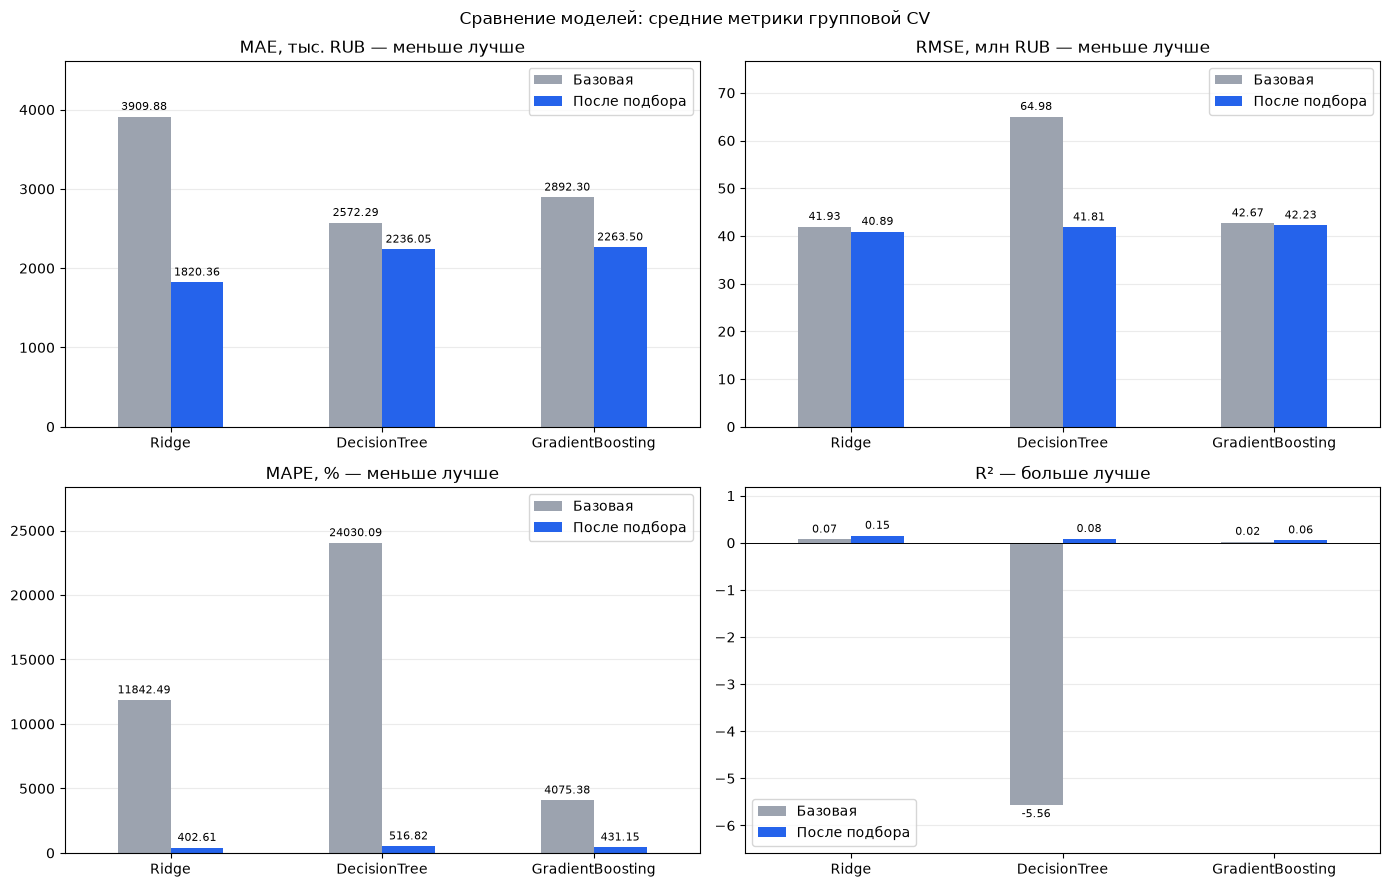

In [160]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

for ax, (metric, label, scale) in zip(axes.flat, plot_settings):
    values = pd.DataFrame({
        "Базовая":
            baseline_results.loc[model_order, metric] / scale,
        "После подбора":
            tuned_results.loc[model_order, metric] / scale
    })

    values.plot.bar(
        ax=ax,
        rot=0,
        color=["#9ca3af", "#2563eb"]
    )

    ax.set_title(label)
    ax.set_xlabel("")
    ax.axhline(0, color="black", linewidth=0.7)
    ax.grid(axis="y", alpha=0.25)
    ax.set_axisbelow(True)
    ax.margins(y=0.18)

    for bars in ax.containers:
        ax.bar_label(
            bars,
            fmt="%.2f",
            padding=3,
            fontsize=8
        )

fig.suptitle(
    "Сравнение моделей: средние метрики групповой CV"
)

plt.tight_layout()
plt.show()

In [161]:
# Предварительный лидер по прежней основной метрике
leader_name = tuned_results["MAE_CV"].idxmin()

In [162]:
diagnostic_data = pd.DataFrame({
    "Тип": X_train["listing_type"],
    "Факт": y_train,
    "Прогноз": tuned_oof[leader_name]
})

In [163]:
diagnostic_data["Остаток"] = (
    diagnostic_data["Факт"]
    - diagnostic_data["Прогноз"]
)

In [164]:
nonpositive_diagnostic_predictions = int(
    diagnostic_data["Прогноз"].le(0).sum()
)
print(
    "Неположительных OOF-прогнозов у предварительного лидера:",
    nonpositive_diagnostic_predictions,
)


Неположительных OOF-прогнозов у предварительного лидера: 0


In [165]:
listing_types = sorted(diagnostic_data["Тип"].unique())

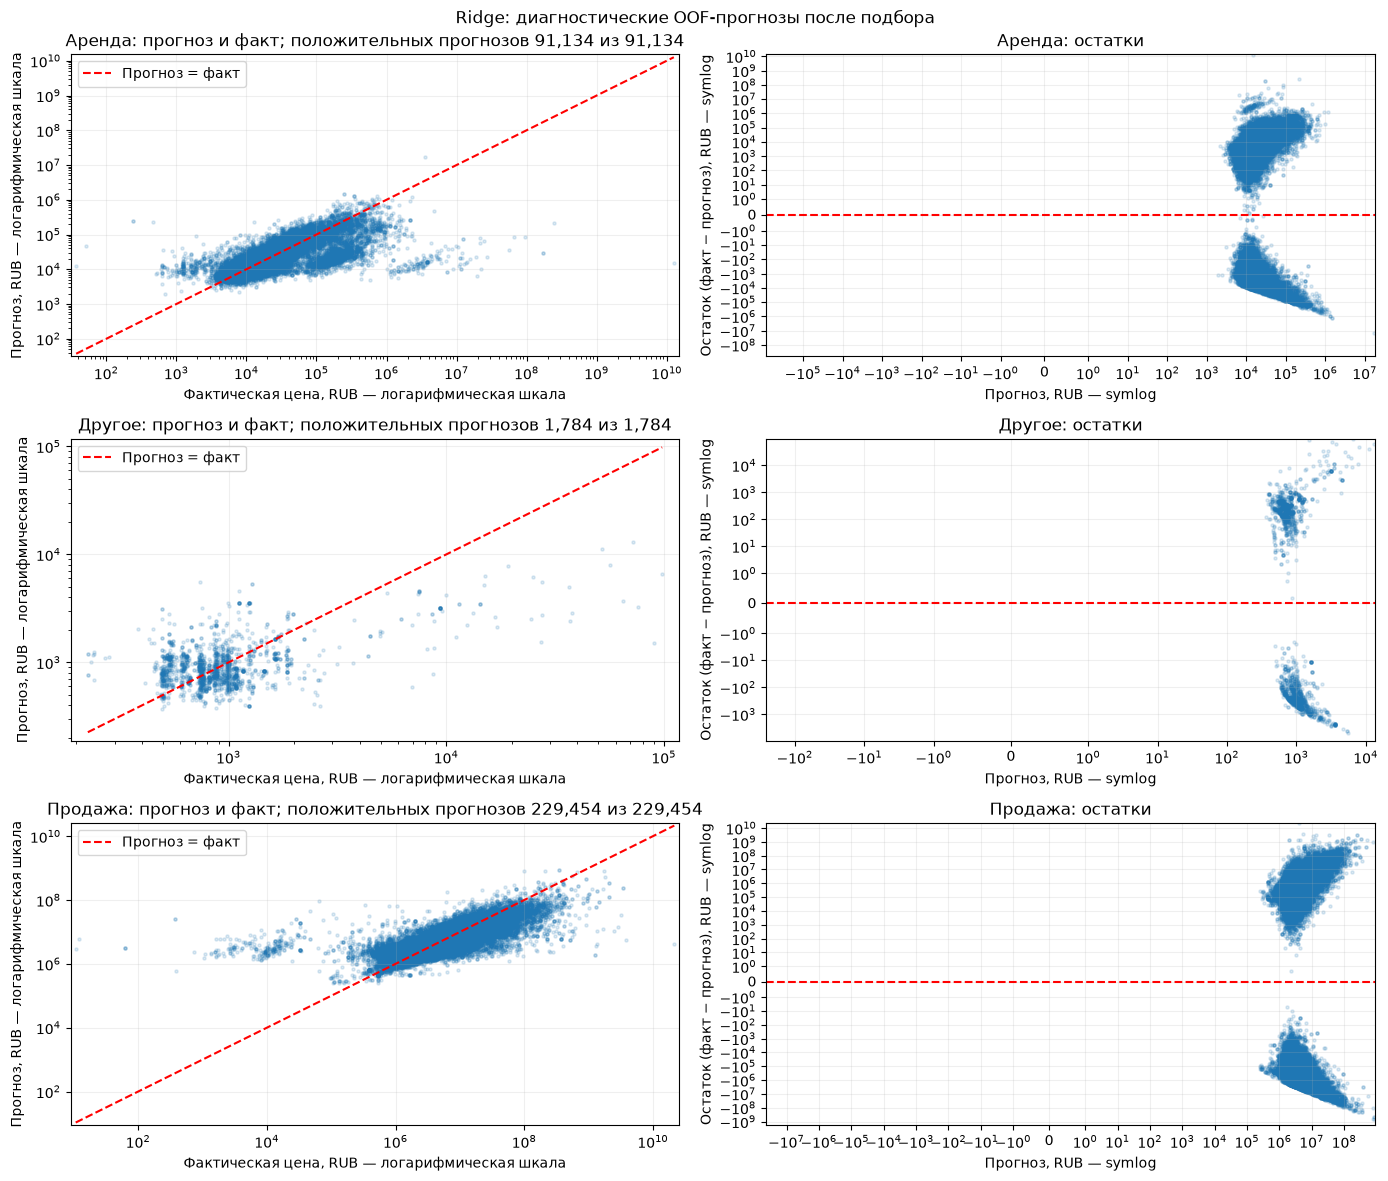

In [166]:
fig, axes = plt.subplots(
    len(listing_types),
    2,
    figsize=(14, 4 * len(listing_types)),
    squeeze=False,
)

for row, listing_type in enumerate(listing_types):
    points = diagnostic_data.loc[
        diagnostic_data["Тип"].eq(listing_type)
    ]
    positive_points = points.loc[
        points["Факт"].gt(0) & points["Прогноз"].gt(0)
    ]

    left, right = axes[row]

    # Для логарифмического графика факт–прогноз нужны положительные значения.
    # Неположительные прогнозы не скрываются: их число напечатано выше, а сами
    # наблюдения остаются на графике остатков справа.
    if positive_points.empty:
        left.text(
            0.5, 0.5, "Нет положительных прогнозов",
            ha="center", va="center", transform=left.transAxes,
        )
    else:
        left.scatter(
            positive_points["Факт"],
            positive_points["Прогноз"],
            s=5,
            alpha=0.15,
        )

        low = positive_points[["Факт", "Прогноз"]].min().min()
        high = positive_points[["Факт", "Прогноз"]].max().max()
        if np.isclose(low, high):
            low, high = low / 1.2, high * 1.2

        left.plot([low, high], [low, high], "r--", label="Прогноз = факт")
        left.set_xscale("log")
        left.set_yscale("log")
        left.set_xlim(low / 1.2, high * 1.2)
        left.set_ylim(low / 1.2, high * 1.2)
        left.legend()

    left.set_xlabel("Фактическая цена, RUB — логарифмическая шкала")
    left.set_ylabel("Прогноз, RUB — логарифмическая шкала")
    left.set_title(
        f"{listing_type}: прогноз и факт; "
        f"положительных прогнозов {len(positive_points):,} из {len(points):,}"
    )

    right.scatter(
        points["Прогноз"],
        points["Остаток"],
        s=5,
        alpha=0.15,
    )
    right.axhline(0, color="red", linestyle="--")
    right.set_xscale("symlog", linthresh=1)
    right.set_yscale("symlog", linthresh=1)
    right.set_xlabel("Прогноз, RUB — symlog")
    right.set_ylabel("Остаток (факт − прогноз), RUB — symlog")
    right.set_title(f"{listing_type}: остатки")

    for ax in [left, right]:
        ax.grid(alpha=0.2)

fig.suptitle(
    f"{leader_name}: диагностические OOF-прогнозы после подбора"
)
plt.tight_layout()
plt.show()


Графики предварительного лидера показывают, насколько прогнозы воспроизводят
различия в фактических ценах. Систематический рисунок и неодинаковый разброс
остатков указывают на ограничения модели, даже если отрицательных прогнозов
нет. Окончательное решение принимается после анализа признаков и ошибок.


#### Анализ коэффициентов и важности признаков

Для интерпретации используются настроенные модели, обученные на всём train.
Коэффициенты Ridge относятся к выбранной при настройке шкале цели и к уже
преобразованным признакам, поэтому не выражают прямое изменение цены в рублях.
Для деревьев показывается MDI-важность; она описывает работу модели, но не
доказывает причинное влияние признаков на стоимость. Test не используется.


In [167]:
feature_labels = {
    "size": "Площадь",
    "rooms_total": "Всего комнат",
    "living_rooms": "Гостиные",
    "listing_time_days": "Время публикации",
    "rooms_missing": "Неизвестная планировка",
    "listing_type": "Тип объявления",
    "sub_type": "Подтип недвижимости",
    "heating_type": "Отопление",
    "floor_no": "Этаж",
    "building_age": "Возраст здания",
    "total_floor_count": "Этажность здания",
    "address": "Адрес"
}

In [168]:
def feature_source(name):
    # Полные префиксы именно нашей предобработки.
    direct = {
        "size__size": "size",
        "rooms__rooms_total": "rooms_total",
        "rooms__living_rooms": "living_rooms",
        "time__listing_time_days": "listing_time_days",
        "binary__rooms_missing": "rooms_missing"
    }

    matches = [direct[name]] if name in direct else []

    for column in ["building_age", "total_floor_count"]:
        if name in [
            f"categories__ordinal__{column}",
            f"categories__ordinal__missingindicator_{column}"
        ]:
            matches.append(column)

    for column in [
        "listing_type", "sub_type", "heating_type", "floor_no"
    ]:
        if name.startswith(f"categories__nominal__{column}_"):
            matches.append(column)

    if name.startswith("categories__address__address_"):
        matches.append("address")

    if len(matches) != 1:
        raise ValueError(
            f"Не удалось однозначно сопоставить признак: {name}"
        )

    return matches[0]

In [169]:
def fitted_feature_table(model_name):
    wrapped = best_models[model_name]
    fitted_pipeline = wrapped.regressor_
    fitted_preprocessor = fitted_pipeline.named_steps["preprocess"]
    fitted_model = fitted_pipeline.named_steps["model"]

    names = fitted_preprocessor.get_feature_names_out()
    assert len(names) == fitted_model.n_features_in_
    assert len(set(names)) == len(names)

    table = pd.DataFrame({"Признак после обработки": names})
    table["Признак до кодирования"] = (
        table["Признак после обработки"].map(feature_source)
    )
    return fitted_model, fitted_preprocessor, table


In [170]:
ridge_model, ridge_preprocessor, ridge_coefficients = (
    fitted_feature_table("Ridge")
)

ridge_coefficients["Коэффициент"] = (
    np.asarray(ridge_model.coef_).ravel()
)

assert np.isfinite(ridge_coefficients["Коэффициент"]).all()

ridge_coefficients["Модуль коэффициента"] = (
    ridge_coefficients["Коэффициент"].abs()
)

ridge_coefficients = ridge_coefficients.sort_values(
    "Модуль коэффициента",
    ascending=False
)

Топ коэффициентов нужен, чтобы посмотреть, на какие признаки модель сильно реагирует в плюс или в минус.

In [171]:
ridge_target_label = (
    f"log({target})" if best_models["Ridge"].func is np.log else target
)
print(
    "20 наибольших по модулю коэффициентов; цель —",
    ridge_target_label,
)
display(ridge_coefficients.head(20).round(4))


20 наибольших по модулю коэффициентов; цель — log(price_rub)


,Признак после обработки,Признак до кодирования,Коэффициент,Модуль коэффициента
6,categories__nominal__listing_type_Продажа,listing_type,5.3835,5.3835
2417,categories__address__address_İstanbul/Şişli/Ha...,address,2.8171,2.8171
1983,categories__address__address_İstanbul/Beşiktaş...,address,2.6404,2.6404
2264,categories__address__address_İstanbul/Sarıyer/...,address,2.6271,2.6271
5,categories__nominal__listing_type_Другое,listing_type,-2.5886,2.5886
1991,categories__address__address_İstanbul/Beşiktaş...,address,2.5400,2.5400
2275,categories__address__address_İstanbul/Sarıyer/...,address,2.4242,2.4242
1982,categories__address__address_İstanbul/Beşiktaş...,address,2.2518,2.2518
2644,categories__address__address_İzmir/Çeşme/Celal...,address,2.2511,2.2511
1998,categories__address__address_İstanbul/Beşiktaş...,address,2.1758,2.1758


In [172]:
print("Коэффициенты остальных характеристик")
with pd.option_context("display.max_rows", None):
    display(
        ridge_coefficients.loc[
            ridge_coefficients["Признак до кодирования"].ne("address")
        ].round(4)
    )


Коэффициенты остальных характеристик


,Признак после обработки,Признак до кодирования,Коэффициент,Модуль коэффициента
6,categories__nominal__listing_type_Продажа,listing_type,5.3835,5.3835
5,categories__nominal__listing_type_Другое,listing_type,-2.5886,2.5886
15,categories__nominal__sub_type_Сборный дом,sub_type,-1.6357,1.6357
10,categories__nominal__sub_type_Кооператив,sub_type,-1.1363,1.1363
12,categories__nominal__sub_type_Особняк / Конак ...,sub_type,0.7427,0.7427
4,binary__rooms_missing,rooms_missing,0.5521,0.5521
8,categories__nominal__sub_type_Квартира,sub_type,-0.5458,0.5458
9,categories__nominal__sub_type_Квартира у воды,sub_type,0.4505,0.4505
25,categories__nominal__heating_type_Печь (уголь),heating_type,-0.4084,0.4084
59,categories__nominal__floor_no_Подвал,floor_no,-0.3863,0.3863


In [173]:
# Базовые категории нужны для интерпретации One-Hot коэффициентов
nominal_fitted = (
    ridge_preprocessor
    .named_transformers_["categories"]
    .named_transformers_["nominal"]
)

reference_categories = pd.DataFrame({
    "Признак": nominal_fitted.feature_names_in_,
    "Базовая категория": [
        categories[int(drop_index)]
        for categories, drop_index in zip(
            nominal_fitted.categories_,
            nominal_fitted.drop_idx_
        )
    ]
})

display(reference_categories)

,Признак,Базовая категория
0,listing_type,Аренда
1,sub_type,Вилла
2,heating_type,Kalorifer (Akaryakıt)
3,floor_no,1


In [174]:
address_fitted = (
    ridge_preprocessor
    .named_transformers_["categories"]
    .named_transformers_["address"]
)

In [175]:
address_base = address_fitted.categories_[0][
    int(address_fitted.drop_idx_[0])
]

In [176]:
rare_addresses = address_fitted.infrequent_categories_[0]

In [177]:
if rare_addresses is not None and address_base in rare_addresses:
    address_base = "Группа редких адресов"

In [178]:
print("Базовая категория адреса:", address_base)

Базовая категория адреса: Adana/Kozan/Karacaoğlan


In [179]:
ridge_top = (
    ridge_coefficients.head(20)
    .sort_values("Коэффициент")
)


In [180]:
ridge_plot_labels = (
    ridge_top["Признак после обработки"]
    .str.replace(
        "categories__address__address_",
        "Адрес: ",
        regex=False
    )
    .str.replace(
        "categories__nominal__listing_type_",
        "Тип объявления: ",
        regex=False
    )
)

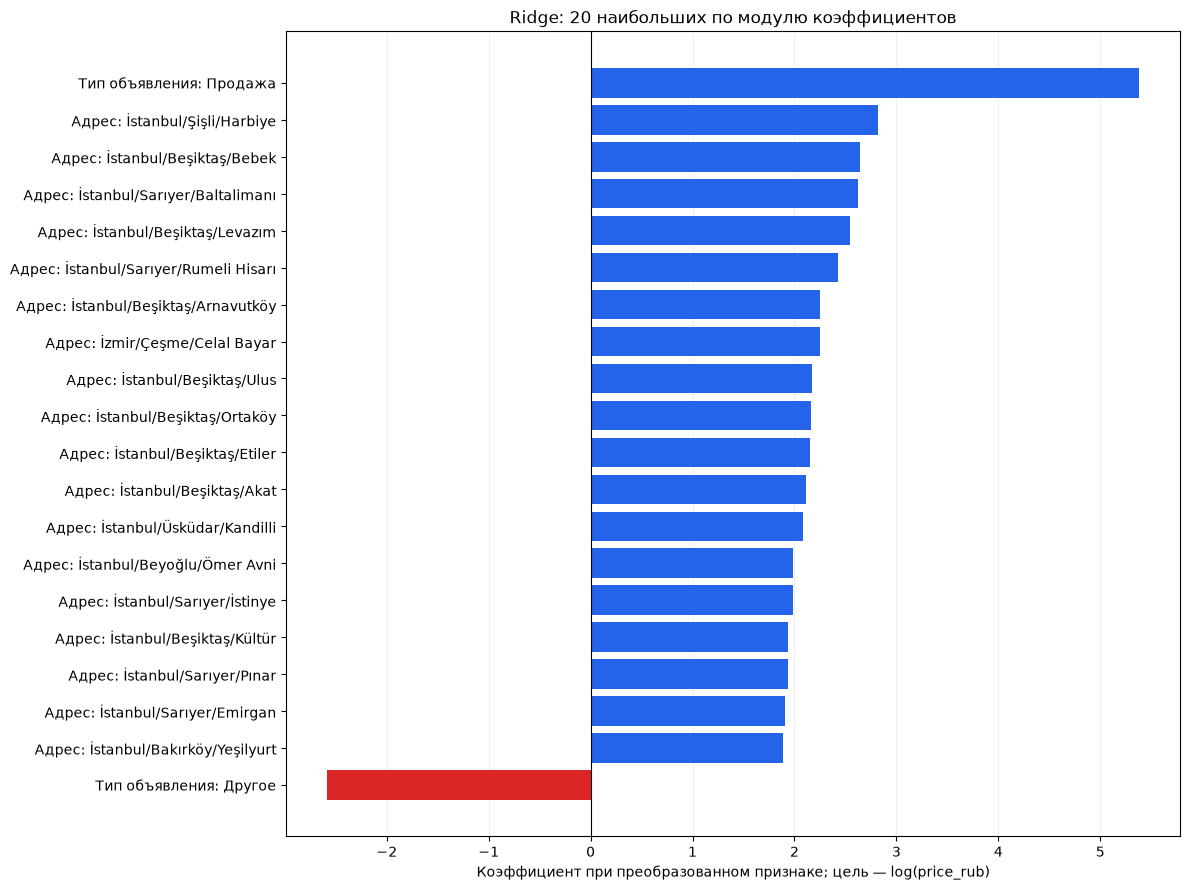

In [181]:
fig, ax = plt.subplots(figsize=(12, 9))

ax.barh(
    ridge_plot_labels,
    ridge_top["Коэффициент"],
    color=np.where(
        ridge_top["Коэффициент"] >= 0,
        "#2563eb",
        "#dc2626"
    )
)

ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Ridge: 20 наибольших по модулю коэффициентов")
ax.set_xlabel(
    "Коэффициент при преобразованном признаке; "
    f"цель — {ridge_target_label}"
)
ax.grid(axis="x", alpha=0.2)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

Синий столбец означает положительную связь с прогнозом, красный — отрицательную.Это описание того, как именно обученная модель использует признаки

**Интерпретация коэффициентов Ridge**

Знак коэффициента показывает направление связи прогноза с преобразованным
признаком при прочих равных. Для One-Hot-категорий сравнение выполняется с
базовой категорией, указанной в таблице выше. Площадь логарифмирована и
масштабирована, а шкала цели выбирается по CV и выводится над таблицей. Поэтому
коэффициенты нельзя трактовать как изменение стоимости на фиксированное число
рублей.


In [182]:
tree_importances = {}
grouped_importances = {}

for name in ["DecisionTree", "GradientBoosting"]:
    fitted_model, _, table = fitted_feature_table(name)

    table["Важность MDI"] = fitted_model.feature_importances_

    assert np.isfinite(table["Важность MDI"]).all()
    assert table["Важность MDI"].ge(0).all()
    assert np.isclose(table["Важность MDI"].sum(), 1)

    tree_importances[name] = table.sort_values(
        "Важность MDI",
        ascending=False
    )

    # Складываем важности всех выходов одного входного признака.
    # Например, категории адреса или ранг возраста и индикатор
    # его пропуска.
    grouped = (
        table.groupby("Признак до кодирования")["Важность MDI"]
        .sum()
    )

    assert np.isclose(
        grouped.sum(),
        table["Важность MDI"].sum()
    )

    grouped_importances[name] = grouped

    print(f"{name}: 15 самых важных признаков после обработки")
    display(tree_importances[name].head(15).round(4))

importance_by_feature = (
    pd.DataFrame(grouped_importances)
    .reindex(feature_labels)
)

assert importance_by_feature.notna().all().all()

print("Суммарная важность по признакам до кодирования, %")
display(
    (100 * importance_by_feature)
    .rename(index=feature_labels)
    .round(2)
)

DecisionTree: 15 самых важных признаков после обработки


,Признак после обработки,Признак до кодирования,Важность MDI
6,categories__nominal__listing_type_Продажа,listing_type,0.9407
1,rooms__rooms_total,rooms_total,0.0218
8,categories__nominal__sub_type_Квартира,sub_type,0.0072
5,categories__nominal__listing_type_Другое,listing_type,0.0070
70,categories__ordinal__total_floor_count,total_floor_count,0.0039
0,size__size,size,0.0033
3,time__listing_time_days,listing_time_days,0.0014
69,categories__ordinal__building_age,building_age,0.0013
25,categories__nominal__heating_type_Печь (уголь),heating_type,0.0007
2683,categories__address__address_infrequent_sklearn,address,0.0007


GradientBoosting: 15 самых важных признаков после обработки


,Признак после обработки,Признак до кодирования,Важность MDI
6,categories__nominal__listing_type_Продажа,listing_type,0.9486
1,rooms__rooms_total,rooms_total,0.0170
8,categories__nominal__sub_type_Квартира,sub_type,0.0089
5,categories__nominal__listing_type_Другое,listing_type,0.0068
0,size__size,size,0.0053
70,categories__ordinal__total_floor_count,total_floor_count,0.0026
25,categories__nominal__heating_type_Печь (уголь),heating_type,0.0008
15,categories__nominal__sub_type_Сборный дом,sub_type,0.0008
2683,categories__address__address_infrequent_sklearn,address,0.0006
1998,categories__address__address_İstanbul/Beşiktaş...,address,0.0005


Суммарная важность по признакам до кодирования, %


,DecisionTree,GradientBoosting
Признак до кодирования,,
Площадь,0.33,0.53
Всего комнат,2.18,1.70
Гостиные,0.01,0.00
Время публикации,0.14,0.03
Неизвестная планировка,0.04,0.03
Тип объявления,94.77,95.54
Подтип недвижимости,0.92,1.03
Отопление,0.23,0.16
Этаж,0.06,0.01


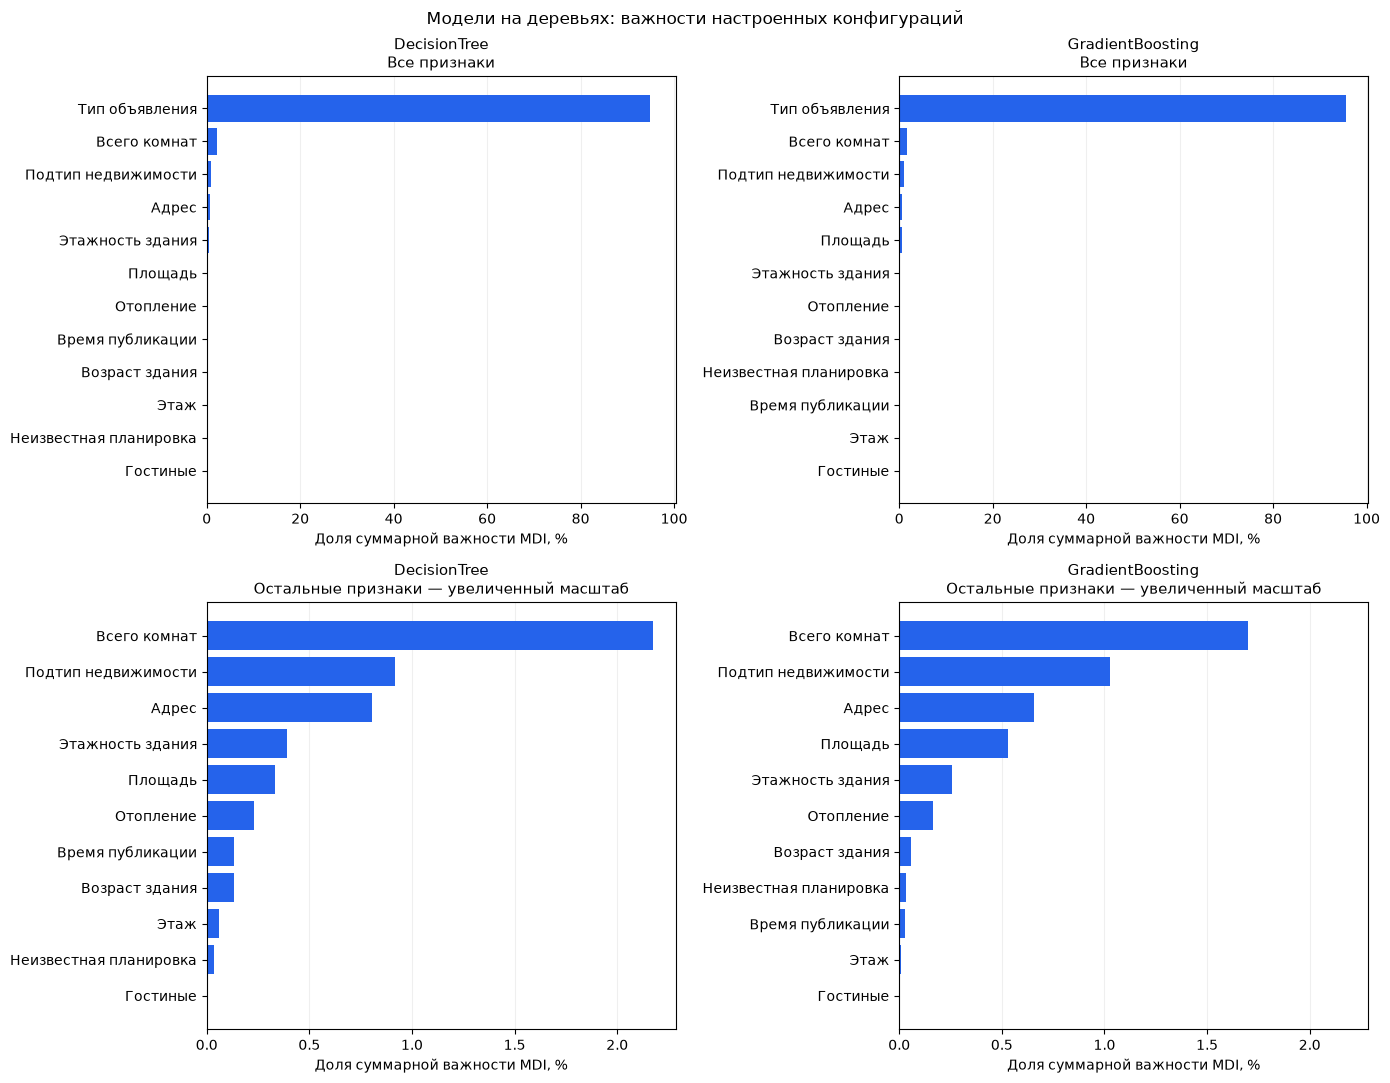

In [183]:
fig, axes = plt.subplots(
    2, 2,
    figsize=(14, 11),
    sharex="row"
)

for column, name in enumerate(
    ["DecisionTree", "GradientBoosting"]
):
    all_values = 100 * importance_by_feature[name]

    for row in [0, 1]:
        # Нижний ряд подробнее показывает остальные признаки.
        # Их доли сохраняются: повторной нормировки нет.
        values = (
            all_values
            if row == 0
            else all_values.drop("listing_type")
        )
        values = values.sort_values()

        ax = axes[row, column]

        ax.barh(
            values.index.map(feature_labels),
            values.values,
            color="#2563eb"
        )

        suffix = (
            "Все признаки"
            if row == 0
            else "Остальные признаки — увеличенный масштаб"
        )

        ax.set_title(f"{name}\n{suffix}", fontsize=11)
        ax.set_xlabel("Доля суммарной важности MDI, %")
        ax.grid(axis="x", alpha=0.2)
        ax.set_axisbelow(True)

fig.suptitle(
    "Модели на деревьях: важности настроенных конфигураций"
)

plt.tight_layout()
plt.show()

**Интерпретация важности признаков**

Таблица показывает, какие исходные характеристики чаще используются моделями
на деревьях для уменьшения ошибки. Важности всех закодированных категорий одного
признака суммированы. MDI может быть смещена в пользу признаков с большим числом
вариантов, поэтому небольшая важность сама по себе не является основанием для
удаления признака.


**Дополнительный анализ крупнейших ошибок**

Для лидера по CV исследуются абсолютная ошибка в рублях, квадрат ошибки и
относительная ошибка. Также рассчитывается медианная APE и доля крупнейших
ошибок в общей сумме. Исходные цена и валюта используются только для проверки
подозрительных записей; сами строки не удаляются без подтверждения ошибки.


In [184]:
assert X_train.index.is_unique and df.index.is_unique
assert diagnostic_data.index.equals(X_train.index)
assert y_train.index.equals(X_train.index)
assert groups_train.index.equals(X_train.index)
assert tuned_oof.index.equals(X_train.index)

In [185]:
assert diagnostic_data["Тип"].equals(X_train["listing_type"])
assert np.array_equal(diagnostic_data["Факт"], y_train)
assert np.array_equal(
    diagnostic_data["Прогноз"],
    tuned_oof[leader_name]
)

In [186]:
assert np.isfinite(
    diagnostic_data[["Факт", "Прогноз"]].to_numpy()
).all()
assert diagnostic_data["Факт"].gt(0).all()

In [187]:
error_analysis = diagnostic_data.copy()

In [188]:
error_analysis["Остаток"] = (
    error_analysis["Факт"] - error_analysis["Прогноз"]
)

In [189]:
error_analysis["AE"] = error_analysis["Остаток"].abs()
error_analysis["SE"] = error_analysis["Остаток"].pow(2)
error_analysis["APE_%"] = (
    100 * error_analysis["AE"] / error_analysis["Факт"]
)

In [190]:
assert np.isfinite(
    error_analysis[["AE", "SE", "APE_%"]].to_numpy()
).all()

In [191]:
error_analysis["id"] = df.loc[error_analysis.index, "id"]
error_analysis["group_id"] = groups_train

error_analysis["Строк группы в train"] = (
    groups_train.map(groups_train.value_counts())
)


In [192]:
print(
    f"Анализируем {leader_name}: "
    f"{len(error_analysis):,} OOF-прогнозов"
)

Анализируем Ridge: 322,372 OOF-прогнозов


In [193]:
def top_error_share(values, k=10):
    total = values.sum()
    return (
        100 * values.nlargest(k).sum() / total
        if total > 0
        else np.nan
    )

In [194]:
def summarize_errors(part):
    return {
        "Количество": len(part),
        "MAE, RUB": part["AE"].mean(),
        "RMSE, RUB": np.sqrt(part["SE"].mean()),
        "MAPE, %": part["APE_%"].mean(),
        "Медиана APE, %": part["APE_%"].median(),
        "Топ-10: доля суммы AE, %": top_error_share(part["AE"]),
        "Топ-10: доля суммы SE, %": top_error_share(part["SE"]),
        "Топ-10: доля суммы APE, %": top_error_share(part["APE_%"])
    }

In [195]:
error_rows = [{
    "Выборка": "Весь train",
    **summarize_errors(error_analysis)
}]
for listing_type, part in error_analysis.groupby("Тип", sort=True):
    error_rows.append({
        "Выборка": f"Тип {listing_type}",
        **summarize_errors(part)
    })

In [196]:
error_summary = (
    pd.DataFrame(error_rows)
    .set_index("Выборка")
)

In [197]:
print("Метрики по объединённым OOF-прогнозам")
display(error_summary.iloc[:, :5].round(2))

Метрики по объединённым OOF-прогнозам


,Количество,"MAE, RUB","RMSE, RUB","MAPE, %","Медиана APE, %"
Выборка,,,,,
Весь train,322372,1819584.21,48731339.31,402.89,19.58
Тип Аренда,91134,169246.75,41944293.63,36.23,20.53
Тип Другое,1784,927.67,4851.34,46.83,31.66
Тип Продажа,229454,2489201.37,51357939.45,551.29,19.17


In [198]:
print(
    "Концентрация ошибок: доли десяти крупнейших "
    "значений в каждой выборке"
)
display(error_summary.iloc[:, 5:].round(4))

Концентрация ошибок: доли десяти крупнейших значений в каждой выборке


,"Топ-10: доля суммы AE, %","Топ-10: доля суммы SE, %","Топ-10: доля суммы APE, %"
Выборка,,,
Весь train,9.6934,90.3495,82.4959
Тип Аренда,87.7800,99.9962,12.2433
Тип Другое,34.1058,86.4535,5.5815
Тип Продажа,8.0383,88.2987,84.7037


In [199]:
top_absolute_errors = error_analysis.nlargest(10, "AE")
top_relative_errors = error_analysis.nlargest(10, "APE_%")

In [200]:
detail_columns = [
    "id", "Тип", "Факт", "Прогноз", "AE", "APE_%",
    "group_id", "Строк группы в train"
]

In [201]:
detail_names = {
    "Факт": "Факт, RUB",
    "Прогноз": "Прогноз, RUB",
    "AE": "Абсолютная ошибка, RUB",
    "APE_%": "Относительная ошибка, %"
}

In [202]:
for title, table in [
    ("10 наибольших ошибок в рублях", top_absolute_errors),
    ("10 наибольших относительных ошибок", top_relative_errors)
]:
    print(title)

    with pd.option_context(
        "display.float_format",
        lambda value: f"{value:,.2f}".replace(",", " ")
    ):
        display(
            table[detail_columns].rename(columns=detail_names)
        )

10 наибольших ошибок в рублях


,id,Тип,"Факт, RUB","Прогноз, RUB","Абсолютная ошибка, RUB","Относительная ошибка, %",group_id,Строк группы в train
392156,392157,Продажа,21 555 973 266.50,4 157 671.38,21 551 815 595.12,99.98,282628,2
397627,397628,Аренда,12 656 608 412.82,14 679.03,12 656 593 733.79,100.00,294582,1
13209,13210,Продажа,3 763 132 461.63,5 431 470.05,3 757 700 991.58,99.86,10552,1
328479,328480,Продажа,3 254 771 606.26,34 728 872.41,3 220 042 733.86,98.93,243500,1
369884,369885,Продажа,3 435 889 540.50,243 405 133.71,3 192 484 406.78,92.92,273278,2
371170,371171,Продажа,3 435 889 540.50,243 405 133.71,3 192 484 406.78,92.92,273278,2
103704,103705,Продажа,2 882 266 861.27,13 859 503.40,2 868 407 357.87,99.52,78829,1
1319,1320,Продажа,2 476 708 600.26,10 695 244.28,2 466 013 355.98,99.57,1102,1
99412,99413,Продажа,2 105 867 782.88,128 593 481.09,1 977 274 301.79,93.89,75535,2
112630,112631,Продажа,2 105 867 782.88,128 593 481.09,1 977 274 301.79,93.89,75535,2


10 наибольших относительных ошибок


,id,Тип,"Факт, RUB","Прогноз, RUB","Абсолютная ошибка, RUB","Относительная ошибка, %",group_id,Строк группы в train
126061,126062,Продажа,12.21,6 166 986.42,6 166 974.21,50 521 638.67,94660,1
233698,233699,Продажа,10.70,2 912 523.42,2 912 512.72,27 228 650.56,174087,1
370081,370082,Продажа,376.23,25 975 531.10,25 975 154.87,6 903 998.41,273463,2
373947,373948,Продажа,376.23,25 975 531.10,25 975 154.87,6 903 998.41,273463,2
397991,397992,Продажа,62.73,3 043 309.02,3 043 246.29,4 851 567.75,294792,3
400776,400777,Продажа,62.73,3 043 309.02,3 043 246.29,4 851 567.75,294792,3
400780,400781,Продажа,62.73,3 043 309.02,3 043 246.29,4 851 567.75,294792,3
378297,378298,Продажа,1 630.53,6 201 438.64,6 199 808.11,380 233.05,279735,6
342562,342563,Продажа,740.01,2 419 610.71,2 418 870.70,326 869.63,254232,1
401539,401540,Продажа,1 902.28,6 201 438.64,6 199 536.35,325 899.76,279735,6


In [203]:
# Объединяем индексы двух списков
# Одну строку не показываем дважды
review_indices = top_absolute_errors.index.union(
    top_relative_errors.index,
    sort=False
)

source_review = df.loc[
    review_indices,
    [
        "id", "listing_type", "start_date",
        "price", "price_currency", "size",
        "room_count", "sub_type", "address"
    ]
].copy()

print(
    "Исходные данные выбранных строк; "
    "price указана в price_currency"
)

with pd.option_context(
    "display.max_columns", None,
    "display.max_colwidth", None,
    "display.float_format",
    lambda value: f"{value:,.2f}".replace(",", " ")
):
    display(source_review)

Исходные данные выбранных строк; price указана в price_currency


,id,listing_type,start_date,price,price_currency,size,room_count,sub_type,address
392156,392157,Продажа,9/26/18,2 000 000 000.00,TRY,NaN,+,Квартира,Mersin/Toroslar/Mithat Toroğlu
397627,397628,Аренда,2/17/19,999 999 100.00,TRY,160.00,3+1,Квартира,Samsun/Atakum/Mevlana
13209,13210,Продажа,1/27/19,300 000 000.00,TRY,130.00,3+1,Квартира,İstanbul/Bağcılar/Merkez
328479,328480,Продажа,12/7/18,260 000 000.00,TRY,28 323.00,+,Целое здание,İstanbul/Şişli/Mecidiyeköy
369884,369885,Продажа,10/11/18,310 000 000.00,TRY,NaN,10+0,Особняк / Конак / У воды,İstanbul/Üsküdar/Kandilli
371170,371171,Продажа,10/11/18,310 000 000.00,TRY,NaN,10+0,Особняк / Конак / У воды,İstanbul/Üsküdar/Kandilli
103704,103705,Продажа,10/22/18,250 000 000.00,TRY,NaN,+,Целое здание,Adana/Yumurtalık/Akyuva
1319,1320,Продажа,2/26/19,200 000 000.00,TRY,140.00,+,Целое здание,İstanbul/Fatih/Rüstem Paşa
99412,99413,Продажа,10/11/18,190 000 000.00,TRY,NaN,5+2,Особняк / Конак / У воды,İstanbul/Sarıyer/Yeniköy
112630,112631,Продажа,10/11/18,190 000 000.00,TRY,NaN,5+2,Особняк / Конак / У воды,İstanbul/Sarıyer/Yeniköy


**Вывод по анализу крупнейших ошибок**

Сравнение MAE, RMSE, средней и медианной APE показывает, насколько итоговые
метрики зависят от небольшого числа экстремальных объявлений. Исходные цены
проверяются вместе с валютой: значения вроде 1 или 5 TRY и чрезвычайно крупные
цены требуют проверки по первоисточнику. Большая ошибка прогноза сама по себе
не является достаточным основанием автоматически удалить строку.


### 3.5 Выбор финальной модели

In [204]:
from time import perf_counter

In [205]:
speed_sample = X_train.sample(
    n=min(1000, len(X_train)),
    random_state=random_state
)

In [206]:
single_requests = [
    speed_sample.iloc[[i]].copy()
    for i in range(min(10, len(speed_sample)))
]


In [207]:
speed_rows = []

for name, model in best_models.items():
    # Прогрев перед измерением
    model.predict(speed_sample)
    model.predict(single_requests[0])

    single_times, batch_times = [], []

    for _ in range(5):
        for request in single_requests:
            started = perf_counter()
            model.predict(request)
            single_times.append(
                1000 * (perf_counter() - started)
            )

        started = perf_counter()
        model.predict(speed_sample)
        batch_times.append(
            1000 * (perf_counter() - started)
        )

    speed_rows.append({
        "Модель": name,
        "Одно объявление, мс": np.median(single_times),
        "Пакет, мс": np.median(batch_times)
    })


In [208]:
prediction_speed = (
    pd.DataFrame(speed_rows).set_index("Модель")
)

In [209]:
selection_table = tuned_results[
    ["MAE_CV", "MAE_CV_std", "MAE_train"]
].join(prediction_speed)


In [210]:
selection_table["Разрыв CV/train, %"] = (
    100 * (
        selection_table["MAE_CV"]
        / selection_table["MAE_train"] - 1
    )
)

In [211]:
print(
    f"Размер пакета для измерения скорости: "
    f"{len(speed_sample)} строк"
)
display(selection_table.round(3))

Размер пакета для измерения скорости: 1000 строк


,MAE_CV,MAE_CV_std,MAE_train,"Одно объявление, мс","Пакет, мс","Разрыв CV/train, %"
Модель,,,,,,
Ridge,1820355.243,158172.121,1784640.683,56.082,64.479,2.001
DecisionTree,2236047.834,148148.821,1990051.650,53.282,61.164,12.361
GradientBoosting,2263500.552,152224.012,2256532.784,56.474,64.363,0.309


In [212]:
# Финальную модель выбираем до обращения к test — только по результатам CV.
final_model_name = tuned_results["MAE_CV"].idxmin()


In [213]:
assert final_model_name in best_models


In [214]:
final_model = best_models[final_model_name]

In [215]:
final_target_scale = (
    f"log({target})" if final_model.func is np.log else target
)


In [216]:
print("Выбрана модель:", final_model_name)
print("Цель при обучении:", final_target_scale)
print("Лучшие параметры:", best_parameters.loc[final_model_name, "Лучшие параметры"])


Выбрана модель: Ridge
Цель при обучении: log(price_rub)
Лучшие параметры: {'alpha': 0.1}


**Обоснование выбора финальной модели**

Финальная модель выбирается по минимальной средней MAE групповой CV до оценки
на test. Дополнительно рассматриваются разброс качества между разбиениями,
разрыв между train и CV, скорость прогнозирования и интерпретируемость.
Отложенный test используется один раз только для итоговой проверки.

In [217]:
assert X_test.index.equals(y_test.index)
assert X_test.index.equals(groups_test.index)
assert list(X_test.columns) == list(X_train.columns)


In [218]:
assert X_train.index.intersection(X_test.index).empty
assert set(groups_train).isdisjoint(set(groups_test))


In [219]:
assert np.isfinite(y_test).all()
assert y_test.gt(0).all()

In [220]:
test_predictions = pd.Series(
    final_model.predict(X_test),
    index=X_test.index,
    name="Прогноз, RUB"
)

C:\Users\polin\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as the infrequent category.
  warnings.warn(msg, UserWarning)


In [221]:
assert np.isfinite(test_predictions).all()

In [222]:
test_rows = [{
    "Выборка": "Весь test",
    "Количество": len(y_test),
    **regression_metrics(y_test, test_predictions)
}]

for listing_type in sorted(X_test["listing_type"].unique()):
    mask = X_test["listing_type"].eq(listing_type)

    test_rows.append({
        "Выборка": f"Тип {listing_type}",
        "Количество": int(mask.sum()),
        **regression_metrics(
            y_test.loc[mask],
            test_predictions.loc[mask]
        )
    })

In [223]:
test_results = (
    pd.DataFrame(test_rows).set_index("Выборка")
)

In [224]:
display(
    test_results.round({
        "MAE": 2,
        "RMSE": 2,
        "MAPE_%": 2,
        "R2": 6
    })
)

,Количество,MAE,RMSE,MAPE_%,R2
Выборка,,,,,
Весь test,80355,1952678.70,71820789.12,839.79,0.077807
Тип Аренда,22967,307997.72,43043285.76,40.65,-0.000043
Тип Другое,450,554.40,1846.42,42.69,0.240824
Тип Продажа,56938,2631519.62,80822820.30,1168.44,0.084688


In [225]:
print(
    "Нулевых прогнозов:",
    int(test_predictions.eq(0).sum())
)
print(
    "Отрицательных прогнозов:",
    int(test_predictions.lt(0).sum())
)


Нулевых прогнозов: 0
Отрицательных прогнозов: 0


**Результаты итоговой проверки**

Таблица выше содержит независимые test-метрики в рублях для всей выборки и
отдельно по типам объявлений. Эти результаты не используются для повторной
настройки модели или удаления неудобных наблюдений. Высокая MAPE, низкий R² или
большое различие качества между группами должны быть явно указаны как
ограничения приложения.


In [226]:
from pathlib import Path
import importlib.util
import json
import platform
from importlib.metadata import version
import joblib


In [227]:
artifact_dir = (PROJECT_DIR / "artifacts").resolve()
artifact_dir.mkdir(parents=True, exist_ok=True)

In [228]:
feature_preparation_source = r'''
import numpy as np
import pandas as pd
RAW_COLUMNS = [
    "size", "room_count", "start_date", "listing_type", "sub_type",
    "heating_type", "floor_no", "building_age", "total_floor_count", "address"
]
MODEL_COLUMNS = [
    "size", "rooms_total", "living_rooms", "listing_time_days", "rooms_missing",
    "listing_type", "sub_type", "heating_type", "floor_no", "building_age",
    "total_floor_count", "address"
]
def prepare_features(raw):
    # size — числовой признак; listing_type и остальные категории — строки
    # start_date имеет формат %m/%d/%y, например "2/17/19"
    result = raw.loc[:, RAW_COLUMNS].copy()

    missing_columns = [
        "building_age", "total_floor_count", "floor_no",
        "heating_type", "room_count"
    ]
    result[missing_columns] = (
        result[missing_columns].fillna("Не указано")
    )

    result["size"] = (
        pd.to_numeric(result["size"], errors="raise").astype(float)
    )
    invalid_size = (
        result["size"].lt(10) | result["size"].gt(10_000) | ~np.isfinite(result["size"])
    )
    result.loc[invalid_size, "size"] = np.nan

    room_parts = (
        result["room_count"].astype("string")
        .str.extract(r"^\s*(\d+)\s*\+\s*(\d+)\s*$")
        .apply(pd.to_numeric, errors="coerce")
        .astype(float)
    )

    result["rooms_total"] = room_parts[0] + room_parts[1]
    result["living_rooms"] = room_parts[1]

    invalid_rooms = (
        room_parts.isna().any(axis=1)
        | result["rooms_total"].le(0)
    )

    result.loc[
        invalid_rooms,
        ["rooms_total", "living_rooms"]
    ] = np.nan

    result["rooms_missing"] = invalid_rooms.astype("int8")

    dates = pd.to_datetime(
        result["start_date"],
        format="%m/%d/%y",
        errors="raise"
    )

    result["listing_time_days"] = (
        dates - pd.Timestamp("2018-01-01")
    ).dt.days

    return result.loc[:, MODEL_COLUMNS]
'''

In [229]:
feature_module_path = artifact_dir / "feature_preparation.py"

In [230]:
feature_module_path.write_text(
    feature_preparation_source.strip() + "\n",
    encoding="utf-8"
)

1903

In [231]:
spec = importlib.util.spec_from_file_location(
    "feature_preparation",
    feature_module_path
)

In [232]:
feature_module = importlib.util.module_from_spec(spec)
spec.loader.exec_module(feature_module)

In [233]:
assert feature_module.MODEL_COLUMNS == list(X_train.columns)

In [234]:
# Проверяем совпадение с прежней подготовкой данных
export_probe = X_train.sample(
    n=min(100, len(X_train)),
    random_state=random_state
)

raw_probe = df.loc[
    export_probe.index,
    feature_module.RAW_COLUMNS
]

prepared_probe = feature_module.prepare_features(raw_probe)

pd.testing.assert_frame_equal(
    prepared_probe,
    export_probe,
    check_dtype=False
)

In [235]:
package_versions = {
    package: version(package)
    for package in [
        "numpy", "pandas", "scipy", "scikit-learn", "joblib"
    ]
}

In [236]:
train_dates = pd.to_datetime(
    df.loc[X_train.index, "start_date"],
    format="%m/%d/%y"
)


In [237]:
selected_parameters = best_parameters.loc[
    final_model_name, "Лучшие параметры"
]

ridge_alpha = None
if final_model_name == "Ridge":
    ridge_alpha = float(
        final_model.regressor_.named_steps["model"].alpha
    )

model_metadata = {
    "schema_version": 2,
    "model_name": final_model_name,
    "alpha": ridge_alpha,
    "best_parameters": selected_parameters,
    "target": target,
    "prediction_currency": "RUB",
    "target_transform": final_target_scale,
    "feature_columns": list(X_train.columns),
    "raw_columns": feature_module.RAW_COLUMNS,
    "feature_module": "feature_preparation.py",
    "date_format": "%m/%d/%y",
    "date_origin": "2018-01-01",
    "training_date_range": [
        str(train_dates.min().date()),
        str(train_dates.max().date()),
    ],
    "random_state": random_state,
    "python_version": platform.python_version(),
    "package_versions": package_versions,
    "cv_metrics": tuned_results.loc[final_model_name].to_dict(),
    "test_metrics": test_results.to_dict(orient="index"),
    "prediction_speed": prediction_speed.loc[final_model_name].to_dict(),
    "prediction_batch_size": len(speed_sample),
}


In [238]:
model_bundle = {
    "model": final_model,
    "metadata": model_metadata
}

In [239]:
model_path = artifact_dir / "price_model.joblib"


In [240]:
joblib.dump(
    model_bundle,
    model_path,
    compress=3
)

['C:\\Users\\polin\\Downloads\\artifacts\\price_model.joblib']

In [241]:
def json_default(value):
    if isinstance(value, np.generic):
        return value.item()
    raise TypeError(f"Объект типа {type(value).__name__} не сериализуется в JSON")


(artifact_dir / "model_metadata.json").write_text(
    json.dumps(
        model_metadata,
        ensure_ascii=False,
        indent=2,
        default=json_default,
    ),
    encoding="utf-8",
)

(artifact_dir / "requirements_model.txt").write_text(
    "\n".join(f"{name}=={value}" for name, value in package_versions.items()) + "\n",
    encoding="utf-8",
)


75

In [242]:
# Загружаем сохранённую модель и сравниваем прогнозы
loaded_bundle = joblib.load(model_path)

In [243]:
expected_predictions = final_model.predict(export_probe)

In [244]:
restored_predictions = (
    loaded_bundle["model"].predict(prepared_probe)
)

In [245]:
np.testing.assert_allclose(
    restored_predictions,
    expected_predictions,
    rtol=1e-12,
    atol=1e-8
)

In [246]:
print(
    "Проверка пройдена: подготовка признаков "
    "и прогнозы после загрузки совпадают."
)

print("Сохранённые файлы:")

for filename in [
    "price_model.joblib",
    "feature_preparation.py",
    "model_metadata.json",
    "requirements_model.txt"
]:
    print(artifact_dir / filename)

Проверка пройдена: подготовка признаков и прогнозы после загрузки совпадают.
Сохранённые файлы:
C:\Users\polin\Downloads\artifacts\price_model.joblib
C:\Users\polin\Downloads\artifacts\feature_preparation.py
C:\Users\polin\Downloads\artifacts\model_metadata.json
C:\Users\polin\Downloads\artifacts\requirements_model.txt


**Сохранение модели и воспроизводимость**

Финальная модель сохраняется вместе с заполнением пропусков, кодированием,
масштабированием и выбранным на CV преобразованием целевой переменной.
Дополнительно создаются модуль подготовки исходных полей, метаданные и точные
версии библиотек. После повторной загрузки прогнозы сравниваются с исходной
моделью. Прогнозы и итоговые метрики выражены в рублях, а поле
`prediction_currency` в метаданных равно `RUB`.
